# Validate personal (FEM) results vs Pablo's WP7.3 optimization reports

Goal: reproduce the manual montage reported in each subject's `Results_summary.txt`
(`Z:\TI\SpatialNavigation\Personalized_Modelling\WP7.3\Optimized\<subject>\`) in our
own SimNIBS FEM pipeline, and minimize the difference between our computed
Hippocampus_R / Entorhinal cortex_R e-field means and the values reported there.

Kept separate from `compare_montages.ipynb` while the method is being validated.
Once differences are minimal, the validated approach can feed back into the main
comparison notebook.

### Setup cell, grab all the folders and results

In [ ]:
# ── Setup ──────────────────────────────────────────────────────────────────
import os, re, json
import numpy as np
# make this independent of the current working directory, here it was on my own hard drive
PROJECT_DIR  = 'D:/MINDS_Project_Karim/BIDS_TI_Toolbox' # Should contain the m2m folders, the configs, etc
ALL_SUBJECTS = ['73T01', '73T02', '73T03', '73T04', '73T05', '73T06', '73T07', '73T09', '73T10', '73T11', '73T12', '73T14']
# Folder with one sub-folder per subject containing Results_summary.txt
RESULTS_DIR = r'Z:\TI\SpatialNavigation\Personalized_Modelling\WP7.3\Optimized' # Z: is Hummel-Dab
E_field_RESULTS_DIR = r"D:\MINDS_Project_Karim\BIDS_TI_Toolbox\derivatives\Pablo_TI_Optimization_WP_73\Efields_Plasma_73_Individualized_Pablo.csv"


### Shared helpers, all the functions we need for validation

In [ ]:
# ── Shared helpers ────────────────────────────────────────────────────────────
import shutil, glob, pathlib, csv, gc
import pandas as pd
import nibabel as nib
import simnibs
from simnibs import sim_struct, mesh_io
from simnibs.utils.transformations import mni2subject_coords
from simnibs.utils import TI_utils as TI
from compare_ti_montages import _vol_mean_capped

# ── Electrode parameters ──────────────────────────────────────────────────────
ELECTRODE_DIMS      = [19.5, 19.5]   # mm diameter (single standard)
ELECTRODE_THICKNESS = [4.]       # [rubber mm, gel mm] — no gel

CACHE_TAGS = [1, 2, 3]   # WM+GM+CSF; read once per variant, filter in Python

# ── Jurak 2007 MNI cap positions ──────────────────────────────────────────────
_jurak_csv = (pathlib.Path(simnibs.__file__).parent
              / 'resources' / 'ElectrodeCaps_MNI' / 'EEG10-10_UI_Jurak_2007.csv')
_jurak = {}
with open(_jurak_csv, newline='') as f:
    for row in csv.reader(f):
        if row and row[0] in ('Electrode', 'ReferenceElectrode'):
            _jurak[row[4].strip()] = np.array([float(row[1]), float(row[2]), float(row[3])])

# ── Pablo CSV ─────────────────────────────────────────────────────────────────
_pablo_df = pd.read_csv(E_field_RESULTS_DIR).set_index('ID')

def get_pablo_efields(subject):
    return _pablo_df.loc[subject].to_dict()

# ── ROI label constants (BNA; odd=Left, even=Right) # LEGACY ───────────────────────────
# HC_LABELS   = frozenset({216, 218})
# EC_LABELS   = frozenset({116})
# VMPFC_R_LBL = frozenset({14, 42, 46, 48, 50, 188})
# VMPFC_L_LBL = frozenset({13, 41, 45, 47, 49, 187})
# RSC_R_LBL   = frozenset({182})
# RSC_L_LBL   = frozenset({181})

# REGIONS = [
#     ('HC',      HC_LABELS),
#     ('EC',      EC_LABELS),
#     ('vmPFC_R', VMPFC_R_LBL),
#     ('vmPFC_L', VMPFC_L_LBL),
#     ('RSC_R',   RSC_R_LBL),
#     ('RSC_L',   RSC_L_LBL),
# ]

# REPORTED_KEY = {
#     'HC':      'Hippocampus_R_u',
#     'EC':      'Entorhinal cortex_R_u',
#     'vmPFC_R': 'vmPFC_R_u',
#     'vmPFC_L': 'vmPFC_L_u',
#     'RSC_R':   'Retrosplenial cortex_R_u',
#     'RSC_L':   'Retrosplenial cortex_L_u',
# }

# ── ROI label sets (BNA atlas, odd=L even=R) ─────────────────────────────────
HC_R_LBL  = frozenset({216, 218})          # rHipp + cHipp, right
HC_L_LBL  = frozenset({215, 217})          # rHipp + cHipp, left
HC_LBL    = HC_R_LBL | HC_L_LBL

EC_R_LBL  = frozenset({116})               # A28/34 (entorhinal), right
EC_L_LBL  = frozenset({115})               # A28/34 (entorhinal), left
EC_LBL    = EC_R_LBL | EC_L_LBL

AMYG_R_LBL = frozenset({212, 214})         # mAmyg + lAmyg, right
AMYG_L_LBL = frozenset({211, 213})         # mAmyg + lAmyg, left
AMYG_LBL   = AMYG_R_LBL | AMYG_L_LBL

# Striatum = caudate (ventral+dorsal) + NAcc + putamen (vm+dl); GP excluded.
# Pablo's exact parcel definition unknown — using standard BNA striatum.
STR_R_LBL  = frozenset({220, 224, 226, 228, 230})
STR_L_LBL  = frozenset({219, 223, 225, 227, 229})
STR_LBL    = STR_R_LBL | STR_L_LBL

# dlPFC = A9/46d + A46 + A9/46v (MFG core, BNA labels 15-22).
# Pablo's exact parcel definition unknown — using standard BNA MFG/dlPFC.
DLPFC_R_LBL = frozenset({16, 20, 22})
DLPFC_L_LBL = frozenset({15, 19, 21})
DLPFC_LBL   = DLPFC_R_LBL | DLPFC_L_LBL

VMPFC_R_LBL = frozenset({14, 42, 46, 48, 50, 188})
VMPFC_L_LBL = frozenset({13, 41, 45, 47, 49, 187})
VMPFC_LBL   = VMPFC_R_LBL | VMPFC_L_LBL

RSC_R_LBL = frozenset({182})
RSC_L_LBL = frozenset({181})
RSC_LBL   = RSC_R_LBL | RSC_L_LBL

# LEGACY single-name aliases (kept for backward compat)
# HC_LABELS = HC_R_LBL; EC_LABELS = EC_R_LBL

REGIONS = [
    ('HC_R',    HC_R_LBL),
    ('HC_L',    HC_L_LBL),
    ('HC',      HC_LBL),
    ('EC_R',    EC_R_LBL),
    ('EC_L',    EC_L_LBL),
    ('EC',      EC_LBL),
    ('Amyg_R',  AMYG_R_LBL),
    ('Amyg_L',  AMYG_L_LBL),
    ('Amyg',    AMYG_LBL),
    ('Str_R',   STR_R_LBL),
    ('Str_L',   STR_L_LBL),
    ('Str',     STR_LBL),
    ('dlPFC_R', DLPFC_R_LBL),
    ('dlPFC_L', DLPFC_L_LBL),
    ('dlPFC',   DLPFC_LBL),
    ('vmPFC_R', VMPFC_R_LBL),
    ('vmPFC_L', VMPFC_L_LBL),
    ('vmPFC',   VMPFC_LBL),
    ('RSC_R',   RSC_R_LBL),
    ('RSC_L',   RSC_L_LBL),
    ('RSC',     RSC_LBL),
]

REPORTED_KEY = {
    'HC_R':    'Hippocampus_R_u',
    'HC_L':    'Hippocampus_L_u',
    'HC':      'Hippocampus_u',
    'EC_R':    'Entorhinal cortex_R_u',
    'EC_L':    'Entorhinal cortex_L_u',
    'EC':      'Entorhinal cortex_u',
    'Amyg_R':  'Amygdala_R_u',
    'Amyg_L':  'Amygdala_L_u',
    'Amyg':    'Amygdala_u',
    'Str_R':   'Striatum_R_u',
    'Str_L':   'Striatum_L_u',
    'Str':     'Striatum_u',
    'dlPFC_R': 'dlPFC_R_u',
    'dlPFC_L': 'dlPFC_L_u',
    'dlPFC':   'dlPFC_u',
    'vmPFC_R': 'vmPFC_R_u',
    'vmPFC_L': 'vmPFC_L_u',
    'vmPFC':   'vmPFC_u',
    'RSC_R':   'Retrosplenial cortex_R_u',
    'RSC_L':   'Retrosplenial cortex_L_u',
    'RSC':     'Retrosplenial cortex_u',
}

# ── Coordinate helpers ────────────────────────────────────────────────────────
def _registered_coords(subject, el_names):
    m2m_path    = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                                f'sub-{subject}', f'm2m_{subject}')
    mni_coords  = np.array([_jurak[n] for n in el_names])
    subj_coords = mni2subject_coords(mni_coords, m2m_path)
    msh_full    = mesh_io.read_msh(os.path.join(m2m_path, f'{subject}.msh'))
    scalp_nodes = msh_full.crop_mesh(tags=[5]).nodes.node_coord
    def snap(c):
        return scalp_nodes[np.argmin(np.linalg.norm(scalp_nodes - c, axis=1))]
    return {n: snap(c) for n, c in zip(el_names, subj_coords)}

def _atlas_elm_labels(subject, project_dir, centroids):
    path = os.path.join(project_dir, 'derivatives', 'SimNIBS',
                        f'sub-{subject}', 'roi',
                        f'sub-{subject}_BNA_atlas_subjectspace.nii.gz')
    img  = nib.load(path)
    data = np.asarray(img.dataobj, dtype=np.int32)
    inv  = np.linalg.inv(img.affine)
    ones = np.ones((len(centroids), 1))
    vox  = (inv @ np.hstack([centroids, ones]).T).T[:, :3]
    vi   = np.round(vox).astype(int)
    sh   = data.shape
    ok   = ((vi[:,0]>=0)&(vi[:,0]<sh[0])&
            (vi[:,1]>=0)&(vi[:,1]<sh[1])&
            (vi[:,2]>=0)&(vi[:,2]<sh[2]))
    lbl  = np.zeros(len(centroids), dtype=np.int32)
    lbl[ok] = data[vi[ok,0], vi[ok,1], vi[ok,2]]
    return lbl

def _read_electrode_centres_from_log(log_path):
    txt = open(log_path, errors='replace').read()
    return [list(map(float, c.split(',')))
            for c in re.findall(r'centre:\s*\[([^\]]+)\]', txt)]

def _mesh_geometry_and_field_tagged(msh_path, tags):
    mt          = mesh_io.read_msh(msh_path).crop_mesh(tags=tags)
    nodes       = mt.nodes.node_coord
    conn        = mt.elm.node_number_list[:, :4] - 1
    centroids   = nodes[conn].mean(axis=1)
    v0 = nodes[conn[:,0]]; v1_ = nodes[conn[:,1]]
    v2 = nodes[conn[:,2]]; v3  = nodes[conn[:,3]]
    elm_volumes = np.abs(np.einsum('ni,ni->n',
                    v1_-v0, np.cross(v2-v0, v3-v0))) / 6.0
    ef          = next(d for d in mt.elmdata if d.field_name == 'E').value
    return centroids, elm_volumes, ef

# ── TI cache: load if available, build + save if not ─────────────────────────
def _load_or_build_ti_cache(subject, fem_subdir):
    cache_dir  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                               f'sub-{subject}', 'comparison', fem_subdir)
    cache_path = os.path.join(cache_dir, 'ti_cache.npz')

    if os.path.isfile(cache_path):
        print(f'  [cache] {subject}/{fem_subdir}')
        c = np.load(cache_path)
        return c['ti'], c['elm_volumes'], c['elm_tags'], c['elm_lbl']

    print(f'  [build] {subject}/{fem_subdir} (will cache) ...')
    ch1 = sorted(glob.glob(os.path.join(cache_dir, 'ch1', '*.msh')))
    ch2 = sorted(glob.glob(os.path.join(cache_dir, 'ch2', '*.msh')))
    if not ch1 or not ch2:
        raise FileNotFoundError(f'FEM meshes missing for {subject}/{fem_subdir}')

    mt1         = mesh_io.read_msh(ch1[0]).crop_mesh(tags=CACHE_TAGS)
    nodes       = mt1.nodes.node_coord
    conn        = mt1.elm.node_number_list[:, :4] - 1
    centroids   = nodes[conn].mean(axis=1)
    v0 = nodes[conn[:,0]]; v1_ = nodes[conn[:,1]]
    v2 = nodes[conn[:,2]]; v3  = nodes[conn[:,3]]
    elm_volumes = np.abs(np.einsum('ni,ni->n',
                    v1_-v0, np.cross(v2-v0, v3-v0))) / 6.0
    elm_tags    = mt1.elm.tag1.astype(np.int32)
    ef1         = next(d for d in mt1.elmdata if d.field_name == 'E').value
    del mt1; gc.collect()

    mt2 = mesh_io.read_msh(ch2[0]).crop_mesh(tags=CACHE_TAGS)
    ef2 = next(d for d in mt2.elmdata if d.field_name == 'E').value
    del mt2; gc.collect()

    ti      = TI.get_maxTI(ef1, ef2)
    del ef1, ef2; gc.collect()

    elm_lbl = _atlas_elm_labels(subject, PROJECT_DIR, centroids)
    del centroids; gc.collect()

    np.savez_compressed(cache_path, ti=ti, elm_volumes=elm_volumes,
                        elm_tags=elm_tags, elm_lbl=elm_lbl)
    return ti, elm_volumes, elm_tags, elm_lbl

# ── Unified FEM runner ────────────────────────────────────────────────────────
def run_manual_fem_channel(subject, plus, minus, current_mA, label, fem_subdir,
                            dimensions=None, coords=None, force=False):
    """
    coords: dict {name: array(3,)} in subject space.
            If None, uses Jurak MNI → mni2subject_coords → scalp-snap.
    dimensions: electrode [w, h] mm. Defaults to ELECTRODE_DIMS.
    """
    if dimensions is None:
        dimensions = ELECTRODE_DIMS

    m2m_path = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                             f'sub-{subject}', f'm2m_{subject}')
    out_dir  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                             f'sub-{subject}', 'comparison', fem_subdir, label)

    if force and os.path.isdir(out_dir):
        print(f'    [force] deleting {label}: {out_dir}')
        shutil.rmtree(out_dir)

    existing = sorted(glob.glob(os.path.join(out_dir, '*.msh')))
    if existing and not force:
        print(f'    [skip] {label}: {os.path.basename(existing[0])}')
        return existing[0]

    os.makedirs(out_dir, exist_ok=True)
    if coords is None:
        coords = _registered_coords(subject, [plus, minus])

    s = sim_struct.SESSION()
    s.subpath = m2m_path; s.pathfem = out_dir; s.open_in_gmsh = False
    tdcs = s.add_tdcslist()
    tdcs.currents = [current_mA * 1e-3, -current_mA * 1e-3]
    for nr, nm in enumerate([plus, minus], 1):
        el = tdcs.add_electrode(); el.channelnr = nr
        el.centre     = coords[nm].tolist()
        el.shape      = 'ellipse'
        el.dimensions = dimensions
        el.thickness  = ELECTRODE_THICKNESS
    simnibs.run_simnibs(s)

    files = sorted(glob.glob(os.path.join(out_dir, '*.msh')))
    if not files:
        raise FileNotFoundError(f'FEM output not found in {out_dir}')
    return files[0]


### Parse results cell from Pablo's results summary files, and the channels and e-fields (There is a new csv file with the new results, and the channel positions are different)

In [23]:
# ── Step 1: parse manual montage channels + currents from Results_summary.txt ─
def parse_results_summary(path):
    txt = open(path).read()
    ch  = re.search(r'Channels:\s+(\w+)-(\w+)\s+and\s+(\w+)-(\w+)', txt)
    cu  = re.search(r'Currents:\s+([\d.]+)\s+and\s+([\d.]+)', txt)
    if not ch or not cu:
        raise ValueError(f'Cannot parse channels/currents from {path}')
    return dict(
        ch1_plus=ch.group(1), ch1_minus=ch.group(2),
        ch2_plus=ch.group(3), ch2_minus=ch.group(4),
        ch1_current_mA=float(cu.group(1)),
        ch2_current_mA=float(cu.group(2)),
    )

# OLD: parse_reported_region_fields (Results_summary.txt 'Average efield on' format)
# def parse_reported_region_fields(path):
#     txt = open(path).read()
#     pairs = re.findall(r'Average efield on (.+?)\s*:\s*([\d.]+)', txt)
#     return {name.strip(): float(val) for name, val in pairs}

manual_cfgs    = {}
reported_hc_ec = {}
for subject in ALL_SUBJECTS:
    summary_txt = os.path.join(RESULTS_DIR, subject, 'Results_summary.txt')
    try:
        manual_cfgs[subject] = parse_results_summary(summary_txt)
        fields = get_pablo_efields(subject)
        reported_hc_ec[subject] = dict(
            hc=fields.get('Hippocampus_R_u'),
            ec=fields.get('Entorhinal cortex_R_u')
        )
        mc = manual_cfgs[subject]
        print(f'sub-{subject}: {mc["ch1_plus"]}-{mc["ch1_minus"]} @ {mc["ch1_current_mA"]} mA | '
              f'{mc["ch2_plus"]}-{mc["ch2_minus"]} @ {mc["ch2_current_mA"]} mA  ->  '
              f'HC={reported_hc_ec[subject]["hc"]}  EC={reported_hc_ec[subject]["ec"]}')
    except Exception as exc:
        print(f'sub-{subject}: ERROR -> {exc}')

reported_hc_ec


sub-73T01: F8-FC3 @ 1.9245 mA | P5-TP10 @ 1.9994 mA  ->  HC=0.3498  EC=0.4572
sub-73T02: F8-FT9 @ 1.7 mA | PO9-CP6 @ 1.7 mA  ->  HC=0.4783  EC=0.4929
sub-73T03: F8-FT9 @ 1.8804 mA | PO9-C6 @ 1.8888 mA  ->  HC=0.4348  EC=0.5243
sub-73T04: F8-FT9 @ 1.9962 mA | PO9-CP6 @ 1.9992 mA  ->  HC=0.4707  EC=0.4013
sub-73T05: F8-FT9 @ 1.9094 mA | PO9-C6 @ 1.8295 mA  ->  HC=0.4713  EC=0.5227
sub-73T06: F6-FT9 @ 1.9982 mA | Iz-CP2 @ 1.9998 mA  ->  HC=0.4034  EC=0.4145
sub-73T07: F8-FT9 @ 1.9994 mA | PO9-CP4 @ 1.9999 mA  ->  HC=0.4477  EC=0.4592
sub-73T09: F8-FT9 @ 1.9996 mA | PO9-CP6 @ 1.9998 mA  ->  HC=0.4211  EC=0.3608
sub-73T10: F8-FT9 @ 1.9993 mA | PO9-CP6 @ 1.9046 mA  ->  HC=0.4551  EC=0.4009
sub-73T11: F8-FT9 @ 1.9998 mA | PO9-CP6 @ 1.9999 mA  ->  HC=0.4796  EC=0.545
sub-73T12: FT8-FT9 @ 1.7849 mA | PO9-CP6 @ 1.9571 mA  ->  HC=0.4598  EC=0.4871
sub-73T14: F6-FT9 @ 1.7997 mA | PO9-T8 @ 1.8 mA  ->  HC=0.4059  EC=0.451


{'73T01': {'hc': 0.3498, 'ec': 0.4572},
 '73T02': {'hc': 0.4783, 'ec': 0.4929},
 '73T03': {'hc': 0.4348, 'ec': 0.5243},
 '73T04': {'hc': 0.4707, 'ec': 0.4013},
 '73T05': {'hc': 0.4713, 'ec': 0.5227},
 '73T06': {'hc': 0.4034, 'ec': 0.4145},
 '73T07': {'hc': 0.4477, 'ec': 0.4592},
 '73T09': {'hc': 0.4211, 'ec': 0.3608},
 '73T10': {'hc': 0.4551, 'ec': 0.4009},
 '73T11': {'hc': 0.4796, 'ec': 0.545},
 '73T12': {'hc': 0.4598, 'ec': 0.4871},
 '73T14': {'hc': 0.4059, 'ec': 0.451}}

In [24]:
# ── Step 2: run manual-montage FEM per channel ───────────────────────────────
# Positions: Jurak 2007 MNI → mni2subject_coords → scalp-snap.
# Electrode: ELECTRODE_DIMS (19.5mm), ELECTRODE_THICKNESS (gel=0).
# Output: comparison/manual_fem_biosemi_64_reg/ch1 and ch2.

FORCE_RERUN = {
    # '73T01': {'ch2'},   # kept for reference; re-add to force a specific rerun
}

manual_msh_paths = {}
for subject in ALL_SUBJECTS:
    print(f'sub-{subject}:')
    mc        = manual_cfgs[subject]
    force_set = FORCE_RERUN.get(subject, set())
    msh1 = run_manual_fem_channel(
        subject, mc['ch1_plus'], mc['ch1_minus'], mc['ch1_current_mA'], 'ch1',
        fem_subdir='manual_fem_biosemi_64_reg', force='ch1' in force_set)
    msh2 = run_manual_fem_channel(
        subject, mc['ch2_plus'], mc['ch2_minus'], mc['ch2_current_mA'], 'ch2',
        fem_subdir='manual_fem_biosemi_64_reg', force='ch2' in force_set)
    manual_msh_paths[subject] = (msh1, msh2)

    ti_cache = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                             f'sub-{subject}', 'comparison',
                             'manual_fem_biosemi_64_reg', 'ti_cache.npz')
    if force_set and os.path.isfile(ti_cache):
        print(f'    [force] deleting stale TI cache: {ti_cache}')
        os.remove(ti_cache)


sub-73T01:
    [skip] ch1: 73T01_TDCS_1_scalar.msh
    [skip] ch2: 73T01_TDCS_1_scalar.msh
sub-73T02:
    [skip] ch1: 73T02_TDCS_1_scalar.msh
    [skip] ch2: 73T02_TDCS_1_scalar.msh
sub-73T03:
    [skip] ch1: 73T03_TDCS_1_scalar.msh
    [skip] ch2: 73T03_TDCS_1_scalar.msh
sub-73T04:
    [skip] ch1: 73T04_TDCS_1_scalar.msh
    [skip] ch2: 73T04_TDCS_1_scalar.msh
sub-73T05:
    [skip] ch1: 73T05_TDCS_1_scalar.msh
    [skip] ch2: 73T05_TDCS_1_scalar.msh
sub-73T06:
    [skip] ch1: 73T06_TDCS_1_scalar.msh
    [skip] ch2: 73T06_TDCS_1_scalar.msh
sub-73T07:
    [skip] ch1: 73T07_TDCS_1_scalar.msh
    [skip] ch2: 73T07_TDCS_1_scalar.msh
sub-73T09:
    [skip] ch1: 73T09_TDCS_1_scalar.msh
    [skip] ch2: 73T09_TDCS_1_scalar.msh
sub-73T10:
    [skip] ch1: 73T10_TDCS_1_scalar.msh
    [skip] ch2: 73T10_TDCS_1_scalar.msh
sub-73T11:
    [skip] ch1: 73T11_TDCS_1_scalar.msh
    [skip] ch2: 73T11_TDCS_1_scalar.msh
sub-73T12:
    [skip] ch1: 73T12_TDCS_1_scalar.msh
    [skip] ch2: 73T12_TDCS_1_scalar.msh

In [25]:
# ── Diagnostic: how far did the scalp-snap move each electrode? ─────────────
# sub-73T01/ch2 (P5-TP10) keeps logging a 35.53% current calibration error,
# identical before and after a clean rerun -> not a fluke, something about
# these two electrode positions. Compare the MNI-warped subject-space position
# (pre-snap) against the nearest-scalp-node position (post-snap, what the FEM
# actually used) for ch2's electrodes, against ch1's (F8/FC3, which ran clean)
# as a baseline.

def _diagnose_snap(subject, el_names):
    m2m_path    = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                                f'sub-{subject}', f'm2m_{subject}')
    mni_coords  = np.array([_jurak[n] for n in el_names])
    subj_coords = mni2subject_coords(mni_coords, m2m_path)
    msh_full    = mesh_io.read_msh(os.path.join(m2m_path, f'{subject}.msh'))
    scalp_nodes = msh_full.crop_mesh(tags=[5]).nodes.node_coord
    for name, pre in zip(el_names, subj_coords):
        dists = np.linalg.norm(scalp_nodes - pre, axis=1)
        idx   = np.argmin(dists)
        post  = scalp_nodes[idx]
        print(f'  {name:>5s}: pre-snap={np.round(pre, 1).tolist()}  '
              f'post-snap={np.round(post, 1).tolist()}  snap_dist={dists[idx]:.2f} mm')

mc = manual_cfgs['73T01']
print('ch1 (F8-FC3, clean run, 1.4% calibration error):')
_diagnose_snap('73T01', [mc['ch1_plus'], mc['ch1_minus']])
print('ch2 (P5-TP10, 35.53% calibration error):')
_diagnose_snap('73T01', [mc['ch2_plus'], mc['ch2_minus']])

# Scalp z-range for reference, to check if TP10 is landing near the neck cutoff
m2m_path = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS', 'sub-73T01', 'm2m_73T01')
msh_full = mesh_io.read_msh(os.path.join(m2m_path, '73T01.msh'))
scalp_z  = msh_full.crop_mesh(tags=[5]).nodes.node_coord[:, 2]
print(f'\nScalp mesh z-range: [{scalp_z.min():.1f}, {scalp_z.max():.1f}] mm')


ch1 (F8-FC3, clean run, 1.4% calibration error):
     F8: pre-snap=[77.8, 69.4, 8.5]  post-snap=[77.0, 69.8, 8.3]  snap_dist=0.85 mm
    FC3: pre-snap=[-52.9, 33.7, 70.0]  post-snap=[-53.3, 34.1, 69.6]  snap_dist=0.69 mm
ch2 (P5-TP10, 35.53% calibration error):
     P5: pre-snap=[-64.7, -60.3, 19.8]  post-snap=[-63.9, -61.1, 19.8]  snap_dist=1.15 mm
   TP10: pre-snap=[89.5, -13.1, -46.6]  post-snap=[88.8, -11.9, -46.2]  snap_dist=1.51 mm

Scalp mesh z-range: [-144.0, 99.4] mm


### Known caveat: sub-73T01/ch2 (P5-TP10) calibration error

Tried nudging TP10 posteriorly (away from the ear) before re-snapping to scalp,
to see if the 35.53% current calibration error was a registration artifact:

| nudge | calibration error |
|-------|--------------------|
| 0 mm (original TP10 position) | 35.53% |
| 10 mm posterior | 31% |
| 20 mm posterior | 10.4% |

20mm gets close to the 10% warning threshold, but moving the electrode that
far means we're no longer simulating *their* TP10 position -- it would defeat
the purpose of this validation (reproducing the reported montage faithfully).
**Decision: keep the original (unnudged) TP10 position and carry the 35.53%
calibration warning as a documented caveat on sub-73T01/ch2 results**, rather
than alter the montage to suppress it.

Code tried (kept for reference, not executed):

```python
NUDGE = {'TP10': dict(direction=np.array([0., -1., 0.]), mm=20.0)}  # posterior

def _registered_coords_nudged(subject, el_names, nudge=None):
    nudge       = nudge or {}
    m2m_path    = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                                f'sub-{subject}', f'm2m_{subject}')
    mni_coords  = np.array([_jurak[n] for n in el_names])
    subj_coords = mni2subject_coords(mni_coords, m2m_path)
    msh_full    = mesh_io.read_msh(os.path.join(m2m_path, f'{subject}.msh'))
    scalp_nodes = msh_full.crop_mesh(tags=[5]).nodes.node_coord
    def snap(c):
        return scalp_nodes[np.argmin(np.linalg.norm(scalp_nodes - c, axis=1))]
    coords_reg = {}
    for name, pre in zip(el_names, subj_coords):
        if name in nudge:
            d, mm = nudge[name]['direction'], nudge[name]['mm']
            pre = pre + (d / np.linalg.norm(d)) * mm
        coords_reg[name] = snap(pre)
    return coords_reg

def run_manual_fem_channel_nudged(subject, plus, minus, current_mA, label, nudge=None, force=False):
    m2m_path = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                             f'sub-{subject}', f'm2m_{subject}')
    out_dir  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                             f'sub-{subject}', 'comparison', 'manual_fem', label)
    if force and os.path.isdir(out_dir):
        shutil.rmtree(out_dir)
    coords_reg = _registered_coords_nudged(subject, [plus, minus], nudge=nudge)
    s = sim_struct.SESSION()
    s.subpath = m2m_path; s.pathfem = out_dir; s.open_in_gmsh = False
    tdcs = s.add_tdcslist()
    tdcs.currents = [current_mA * 1e-3, -current_mA * 1e-3]
    for nr, nm in enumerate([plus, minus], 1):
        el = tdcs.add_electrode(); el.channelnr = nr
        el.centre     = coords_reg[nm].tolist()
        el.shape      = 'ellipse'
        el.dimensions = [14., 14.]
        el.thickness  = [4., 1.]
    simnibs.run_simnibs(s)
    files = sorted(glob.glob(os.path.join(out_dir, '*.msh')))
    return files[0]
```

Current disk state for sub-73T01/comparison/manual_fem/ch2: original (unnudged)
TP10 position, 35.53% calibration error, used as-is going forward.


In [26]:
# ── Step 3: compute HC / EC TI means for manual_fem_biosemi_64_reg ───────────
# Uses _load_or_build_ti_cache — fast on repeat runs.
# HC/EC filtered to WM+GM [1,2] (consistent with Step 12 WM+GM variant).

manual_hc_ec = {}
for subject in ALL_SUBJECTS:
    ti, elm_volumes, elm_tags, elm_lbl = _load_or_build_ti_cache(
        subject, 'manual_fem_biosemi_64_reg')

    wm_gm = np.isin(elm_tags, [1, 2])
    ti_v  = ti[wm_gm]; vols_v = elm_volumes[wm_gm]; lbl_v = elm_lbl[wm_gm]

    hc_mask = np.isin(lbl_v, list(HC_LABELS))
    ec_mask = np.isin(lbl_v, list(EC_LABELS))
    hc_val  = _vol_mean_capped(ti_v[hc_mask], vols_v[hc_mask]) if hc_mask.any() else np.nan
    ec_val  = _vol_mean_capped(ti_v[ec_mask], vols_v[ec_mask]) if ec_mask.any() else np.nan
    manual_hc_ec[subject] = dict(hc=hc_val, ec=ec_val)

    print(f'sub-{subject}: computed HC={hc_val:.4f}  EC={ec_val:.4f}   |   '
          f'reported HC={reported_hc_ec[subject]["hc"]}  EC={reported_hc_ec[subject]["ec"]}')

    del ti, elm_volumes, elm_tags, elm_lbl
    gc.collect()

manual_hc_ec


  [cache] 73T01/manual_fem_biosemi_64_reg
sub-73T01: computed HC=0.3289  EC=0.4300   |   reported HC=0.3498  EC=0.4572
  [cache] 73T02/manual_fem_biosemi_64_reg
sub-73T02: computed HC=0.3511  EC=0.2527   |   reported HC=0.4783  EC=0.4929
  [cache] 73T03/manual_fem_biosemi_64_reg
sub-73T03: computed HC=0.4010  EC=0.4765   |   reported HC=0.4348  EC=0.5243
  [cache] 73T04/manual_fem_biosemi_64_reg
sub-73T04: computed HC=0.4477  EC=0.3246   |   reported HC=0.4707  EC=0.4013
  [cache] 73T05/manual_fem_biosemi_64_reg
sub-73T05: computed HC=0.4101  EC=0.4253   |   reported HC=0.4713  EC=0.5227
  [cache] 73T06/manual_fem_biosemi_64_reg
sub-73T06: computed HC=0.3535  EC=0.3972   |   reported HC=0.4034  EC=0.4145
  [cache] 73T07/manual_fem_biosemi_64_reg
sub-73T07: computed HC=0.3963  EC=0.2979   |   reported HC=0.4477  EC=0.4592
  [cache] 73T09/manual_fem_biosemi_64_reg
sub-73T09: computed HC=0.3792  EC=0.3272   |   reported HC=0.4211  EC=0.3608
  [cache] 73T10/manual_fem_biosemi_64_reg
sub-73

{'73T01': {'hc': 0.3289043748141208, 'ec': 0.4299899873200086},
 '73T02': {'hc': 0.35106031273017424, 'ec': 0.2526696552263008},
 '73T03': {'hc': 0.4009503417643211, 'ec': 0.476537818894932},
 '73T04': {'hc': 0.4477185132391166, 'ec': 0.3246291124039987},
 '73T05': {'hc': 0.4101084123963035, 'ec': 0.4252785563928476},
 '73T06': {'hc': 0.35353067736127775, 'ec': 0.3971780698783354},
 '73T07': {'hc': 0.39625870474698055, 'ec': 0.2979357567124092},
 '73T09': {'hc': 0.3791624663589876, 'ec': 0.32719292647775916},
 '73T10': {'hc': 0.43952943242425535, 'ec': 0.3420799750218301},
 '73T11': {'hc': 0.4133770672048128, 'ec': 0.3944042269453616},
 '73T12': {'hc': 0.348470506322012, 'ec': 0.2909063506422264},
 '73T14': {'hc': 0.401186051405232, 'ec': 0.3819042747209397}}

### ~~Step 4: 20mm electrode size test~~ (obsolete)

Replaced by the single 19.5mm standard (`ELECTRODE_DIMS = [19.5, 19.5]`).
The separate `manual_fem_20mm` Jurak-snapped runs are no longer needed.
Original output remains on disk at `comparison/manual_fem_20mm/` for reference.


In [27]:
# ── Step 4: re-run with 20mm-diameter electrodes, position unchanged ────────
# Isolating electrode size only: same registered positions as manual_fem
# (14mm), just a bigger contact patch. Output goes to a separate
# manual_fem_20mm folder so the original 14mm runs aren't touched and both
# remain available for comparison. Pablo's Electrodes.geo patch extents
# (~17-19mm, tilted on the scalp) suggested ~20mm diameter is plausible.

if False:
    ELECTRODE_DIM_TEST = [20., 20.]

    def run_manual_fem_channel_sized(subject, plus, minus, current_mA, label,
                                    dimensions, fem_subdir, force=False):
        m2m_path = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                                f'sub-{subject}', f'm2m_{subject}')
        out_dir  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                                f'sub-{subject}', 'comparison', fem_subdir, label)

        if force and os.path.isdir(out_dir):
            print(f'    [force] deleting stale {label} run: {out_dir}')
            shutil.rmtree(out_dir)

        existing = sorted(glob.glob(os.path.join(out_dir, '*.msh')))
        if existing and not force:
            print(f'    [skip] {label}: {os.path.basename(existing[0])}')
            return existing[0]

        os.makedirs(out_dir, exist_ok=True)   # SimNIBS only creates one path level itself

        coords_reg = _registered_coords(subject, [plus, minus])
        s = sim_struct.SESSION()
        s.subpath = m2m_path; s.pathfem = out_dir; s.open_in_gmsh = False
        tdcs = s.add_tdcslist()
        tdcs.currents = [current_mA * 1e-3, -current_mA * 1e-3]
        for nr, nm in enumerate([plus, minus], 1):
            el = tdcs.add_electrode(); el.channelnr = nr
            el.centre     = coords_reg[nm].tolist()
            el.shape      = 'ellipse'
            el.dimensions = dimensions
            el.thickness  = [4., 1.]
        simnibs.run_simnibs(s)
        files = sorted(glob.glob(os.path.join(out_dir, '*.msh')))
        if not files:
            raise FileNotFoundError(f'FEM output not found in {out_dir}')
        return files[0]

    manual_msh_paths_20mm = {}
    for subject in ALL_SUBJECTS:
        print(f'sub-{subject}:')
        mc = manual_cfgs[subject]
        msh1 = run_manual_fem_channel_sized(subject, mc['ch1_plus'], mc['ch1_minus'],
                                            mc['ch1_current_mA'], 'ch1',
                                            ELECTRODE_DIM_TEST, 'manual_fem_20mm')
        msh2 = run_manual_fem_channel_sized(subject, mc['ch2_plus'], mc['ch2_minus'],
                                            mc['ch2_current_mA'], 'ch2',
                                            ELECTRODE_DIM_TEST, 'manual_fem_20mm')
        manual_msh_paths_20mm[subject] = (msh1, msh2)


### ~~Step 5: 14mm vs 20mm comparison table~~ (obsolete)

Size comparison superseded by the single 19.5mm standard.
Finding at the time: electrode size (14mm vs 20mm) had negligible effect on HC/EC means (< 1% difference across all subjects).


In [28]:
if False:
    # ── Step 5: compute HC/EC from the 20mm run, compare 14mm vs 20mm vs reported ──

    manual_hc_ec_20mm = {}
    for subject in ALL_SUBJECTS:
        msh1, msh2 = manual_msh_paths_20mm[subject]
        centroids, elm_volumes, ef1 = _mesh_geometry_and_field(msh1)
        _, _, ef2                   = _mesh_geometry_and_field(msh2)
        ti = TI.get_maxTI(ef1, ef2)

        elm_lbl = _atlas_elm_labels(subject, PROJECT_DIR, centroids)
        hc_mask = np.isin(elm_lbl, list(HC_LABELS))
        ec_mask = np.isin(elm_lbl, list(EC_LABELS))

        hc_val = _vol_mean_capped(ti[hc_mask], elm_volumes[hc_mask]) if hc_mask.any() else np.nan
        ec_val = _vol_mean_capped(ti[ec_mask], elm_volumes[ec_mask]) if ec_mask.any() else np.nan
        manual_hc_ec_20mm[subject] = dict(hc=hc_val, ec=ec_val)

        del centroids, elm_volumes, ef1, ef2, ti, elm_lbl, hc_mask, ec_mask
        gc.collect()

    print(f'{"subject":<8} {"HC 14mm":>9} {"HC 20mm":>9} {"HC report":>10} | '
        f'{"EC 14mm":>9} {"EC 20mm":>9} {"EC report":>10}')
    for subject in ALL_SUBJECTS:
        m14 = manual_hc_ec[subject]
        m20 = manual_hc_ec_20mm[subject]
        rep = reported_hc_ec[subject]
        print(f'{subject:<8} {m14["hc"]:>9.4f} {m20["hc"]:>9.4f} {rep["hc"]:>10.4f} | '
            f'{m14["ec"]:>9.4f} {m20["ec"]:>9.4f} {rep["ec"]:>10.4f}')


In [29]:
# ── Step 6: compare registered positions vs Pablo's actual, all subjects ──────
PABLO_ELECTRODES = {
    '73T01': {'F8':  np.array([ 79.368,  64.341,  11.823]),
              'FC3': np.array([-53.803,  37.757,  67.463]),
              'P5':  np.array([-66.290, -55.756,  20.371]),
              'TP10':np.array([ 89.097, -19.398, -40.223])},
    '73T02': {'F8':  np.array([ 62.294,  49.770,   8.302]),
              'FT9': np.array([-65.761,  46.287, -35.900]),
              'PO9': np.array([-53.016, -53.775, -49.465]),
              'CP6': np.array([ 60.836, -37.180,  24.474])},
    '73T03': {'F8':  np.array([ 67.131,  54.390,  13.173]),
              'FT9': np.array([-65.064,  33.019, -34.828]),
              'PO9': np.array([-47.643, -68.280, -34.523]),
              'C6':  np.array([ 78.483,   0.818,  39.325])},
    '73T04': {'F8':  np.array([ 66.798,  57.742,   8.027]),
              'FT9': np.array([-62.761,  31.447, -23.492]),
              'PO9': np.array([-43.924, -69.513, -15.346]),
              'CP6': np.array([ 74.307, -24.001,  42.853])},
    '73T05': {'F8':  np.array([ 69.245,  58.262,  -3.911]),
              'FT9': np.array([-73.792,  33.232, -41.655]),
              'PO9': np.array([-46.691, -71.760, -44.930]),
              'C6':  np.array([ 80.734,   3.287,  22.705])},
    '73T06': {'F6':  np.array([ 70.481,  62.271,  37.675]),
              'FT9': np.array([-71.215,  38.010, -16.771]),
              'Iz':  np.array([ -0.309, -84.805, -35.044]),
              'CP2': np.array([ 47.021, -43.621,  83.625])},
    '73T07': {'F8':  np.array([ 76.021,  51.240, -31.378]),
              'FT9': np.array([-67.048,  47.698, -64.534]),
              'PO9': np.array([-53.154, -57.144, -80.950]),
              'CP4': np.array([ 62.019, -45.921,   8.915])},
    '73T09': {'F8':  np.array([ 75.546,  59.742,  -2.963]),
              'FT9': np.array([-68.273,  42.747, -36.390]),
              'PO9': np.array([-52.131, -64.052, -49.032]),
              'CP6': np.array([ 79.178, -30.334,  15.524])},
    '73T10': {'F8':  np.array([ 54.703,  56.408,  17.154]),
              'FT9': np.array([-75.931,  30.035, -16.890]),
              'PO9': np.array([-52.038, -71.052, -17.024]),
              'CP6': np.array([ 71.340, -26.672,  45.532])},
    '73T11': {'F8':  np.array([ 67.594,  56.282, -27.181]),
              'FT9': np.array([-66.864,  35.144, -58.973]),
              'PO9': np.array([-51.029, -69.744, -60.990]),
              'CP6': np.array([ 74.425, -31.282,  -1.125])},
    '73T12': {'FT8': np.array([ 76.910,  29.564,  -2.747]),
              'FT9': np.array([-70.812,  43.245, -36.498]),
              'PO9': np.array([-57.847, -58.796, -62.468]),
              'CP6': np.array([ 76.131, -31.582,  11.813])},
    '73T14': {'F6':  np.array([ 59.819,  59.101,  25.720]),
              'FT9': np.array([-77.643,  37.528, -33.480]),
              'PO9': np.array([-57.945, -66.447, -43.078]),
              'T8':  np.array([ 75.112,   1.631, -10.580])},
}

print(f'{"subject":<8} {"ch1_plus":<10}{"off":>6}  {"ch1_minus":<10}{"off":>6}  '
      f'{"ch2_plus":<10}{"off":>6}  {"ch2_minus":<10}{"off":>6}')
for subject in ALL_SUBJECTS:
    if subject not in PABLO_ELECTRODES:
        print(f'{subject:<8} [no Pablo electrodes]')
        continue
    mc    = manual_cfgs[subject]
    names = [mc['ch1_plus'], mc['ch1_minus'], mc['ch2_plus'], mc['ch2_minus']]
    try:
        ours  = _registered_coords(subject, names)
    except KeyError as e:
        print(f'{subject:<8} [electrode {e} not in Jurak CSV — skipping offset]')
        continue
    pablo = PABLO_ELECTRODES[subject]
    offs  = [np.linalg.norm(ours[n] - pablo[n]) for n in names]
    print(f'{subject:<8} ' + '  '.join(f'{n:<10}{o:>6.2f}' for n, o in zip(names, offs)))


subject  ch1_plus     off  ch1_minus    off  ch2_plus     off  ch2_minus    off
73T01    F8          6.89  FC3         4.25  P5          5.88  TP10        9.62
73T02    F8          3.17  FT9         3.93  PO9         3.81  CP6         2.82
73T03    F8          2.13  FT9         3.65  PO9         6.84  C6          3.98
73T04    F8          2.21  FT9         3.26  PO9         6.33  CP6         1.34
73T05    F8          4.24  FT9         5.52  PO9         4.91  C6          3.25
73T06    F6          2.53  FT9         4.19  Iz          6.73  CP2         2.99
73T07    F8          2.40  FT9         2.26  PO9         2.35  CP4         1.86
73T09    F8          4.89  FT9         5.61  PO9         5.20  CP6         4.63
73T10    F8          1.48  FT9         6.39  PO9         4.15  CP6         3.26
73T11    F8          3.72  FT9         2.60  PO9         2.68  CP6         1.49
73T12    FT8         4.31  FT9         4.13  PO9         5.59  CP6         3.98
73T14    F6          4.02  FT9         5

### ~~Step 7: global vs per-region percentile cap~~ (investigation complete)

Tested whether Pablo's whole-brain 99th-percentile cap (applied globally) vs our
per-region cap explains the HC/EC gap. **Finding: negligible difference** (< 0.001 V/m
across all subjects and regions). Ruled out as a cause.


In [30]:
if False:
    # ── Step 7: whole-brain-cap vs per-region-cap, compare to reported ──────────
    # Pablo's reply: he caps at the 99th percentile of values across the whole
    # brain, then applies that single threshold everywhere -- not a per-region
    # percentile like our _vol_mean_capped. For a small ROI (EC especially), the
    # in-region 99th percentile is likely much lower than the whole-brain one, so
    # our per-region cap clips harder and would read systematically low, in the
    # same direction as the gap we're seeing. Test directly using the existing
    # manual_fem (14mm) meshes -- no new simulation needed.

    def _vol_mean_capped_global(values, volumes, cap):
        v = np.minimum(values, cap)
        return float((v * volumes).sum() / volumes.sum())

    manual_hc_ec_globalcap = {}
    for subject in ALL_SUBJECTS:
        msh1, msh2 = manual_msh_paths[subject]
        centroids, elm_volumes, ef1 = _mesh_geometry_and_field(msh1)
        _, _, ef2                   = _mesh_geometry_and_field(msh2)
        ti = TI.get_maxTI(ef1, ef2)

        elm_lbl = _atlas_elm_labels(subject, PROJECT_DIR, centroids)
        hc_mask = np.isin(elm_lbl, list(HC_LABELS))
        ec_mask = np.isin(elm_lbl, list(EC_LABELS))

        whole_brain_cap = np.percentile(ti, 99)
        hc_val = _vol_mean_capped_global(ti[hc_mask], elm_volumes[hc_mask], whole_brain_cap) if hc_mask.any() else np.nan
        ec_val = _vol_mean_capped_global(ti[ec_mask], elm_volumes[ec_mask], whole_brain_cap) if ec_mask.any() else np.nan
        manual_hc_ec_globalcap[subject] = dict(hc=hc_val, ec=ec_val)

        del centroids, elm_volumes, ef1, ef2, ti, elm_lbl, hc_mask, ec_mask
        gc.collect()

    print(f'{"subject":<8} {"HC region-cap":>13} {"HC global-cap":>13} {"HC report":>10} | '
          f'{"EC region-cap":>13} {"EC global-cap":>13} {"EC report":>10}')
    for subject in ALL_SUBJECTS:
        reg = manual_hc_ec[subject]
        glb = manual_hc_ec_globalcap[subject]
        rep = reported_hc_ec[subject]
        print(f'{subject:<8} {reg["hc"]:>13.4f} {glb["hc"]:>13.4f} {rep["hc"]:>10.4f} | '
              f'{reg["ec"]:>13.4f} {glb["ec"]:>13.4f} {rep["ec"]:>10.4f}')


### ~~Step 8: ROI mask size sanity check~~ (investigation complete)

Verified BNA atlas registration quality per subject by checking element counts and
volumes in HC and EC masks. All subjects had reasonable mask sizes (HC: 6000–13000
elements, ~6000–7500 mm³; EC: 500–1700 elements, ~700–1000 mm³). No outlier
registrations detected.


In [31]:
if False: 
     # ── Step 8: sanity-check HC/EC mask sizes per subject ───────────────────────
      # Looking for an anomaly in the BNA-atlas-warped mask for any subject
      # (especially 73T02) that would point to a bad charm/atlas-warp registration
      # rather than a montage-reproduction issue.

      print(f'{"subject":<8} {"HC n_elm":>9} {"HC vol(mm3)":>12} {"EC n_elm":>9} {"EC vol(mm3)":>12} {"total n_elm":>12}')
      for subject in ALL_SUBJECTS:
            msh1, _ = manual_msh_paths[subject]
            centroids, elm_volumes, _ = _mesh_geometry_and_field(msh1)
            elm_lbl = _atlas_elm_labels(subject, PROJECT_DIR, centroids)
            hc_mask = np.isin(elm_lbl, list(HC_LABELS))
            ec_mask = np.isin(elm_lbl, list(EC_LABELS))
            print(f'{subject:<8} {hc_mask.sum():>9d} {elm_volumes[hc_mask].sum():>12.1f} '
                  f'{ec_mask.sum():>9d} {elm_volumes[ec_mask].sum():>12.1f} {len(centroids):>12d}')
            del centroids, elm_volumes, elm_lbl, hc_mask, ec_mask
            gc.collect()


### ~~Step 9: electrode polarity test~~ (investigation complete)

Tested all 4 sign combinations of ef1/ef2 passed to `TI.get_maxTI`.
**Finding: completely invariant** — all combinations give identical results.
`TI_utils.py` normalizes E1/E2 internally (forces |E1| ≥ |E2| and angle < 90°)
before computing the envelope, so polarity is by design irrelevant. Ruled out.


In [32]:
if False:
   # ── Step 9: test electrode polarity (anode/cathode) combinations ───────────
    # TI.get_maxTI(ef1, ef2) is NOT invariant to flipping just one channel's
    # polarity -- it changes the relative angle between the two channels' fields
    # at every point, which changes the envelope value (not just its sign).
    # Flipping BOTH channels together should reproduce the original result.
    # Result: all 4 combinations were identical -- get_maxTI's source
    # (TI_utils.py:124-130) normalizes E1/E2 internally (forces |E1|>=|E2| and
    # angle<90deg) before computing the envelope, so it's polarity-invariant by
    # design. Ruled out. Kept here for the record / reproducibility.
    # Reuses the existing manual_fem (14mm) E-fields -- no new simulation needed.

    polarity_results = {}
    for subject in ALL_SUBJECTS:
        msh1, msh2 = manual_msh_paths[subject]
        centroids, elm_volumes, ef1 = _mesh_geometry_and_field(msh1)
        _, _, ef2                   = _mesh_geometry_and_field(msh2)

        elm_lbl = _atlas_elm_labels(subject, PROJECT_DIR, centroids)
        hc_mask = np.isin(elm_lbl, list(HC_LABELS))
        ec_mask = np.isin(elm_lbl, list(EC_LABELS))

        combos = {
            'pp (original)':  TI.get_maxTI( ef1,  ef2),
            'np (flip ch1)':  TI.get_maxTI(-ef1,  ef2),
            'pn (flip ch2)':  TI.get_maxTI( ef1, -ef2),
            'nn (flip both)': TI.get_maxTI(-ef1, -ef2),
        }
        polarity_results[subject] = {}
        for label, ti in combos.items():
            hc_val = _vol_mean_capped(ti[hc_mask], elm_volumes[hc_mask]) if hc_mask.any() else np.nan
            ec_val = _vol_mean_capped(ti[ec_mask], elm_volumes[ec_mask]) if ec_mask.any() else np.nan
            polarity_results[subject][label] = dict(hc=hc_val, ec=ec_val)
            del ti

        del centroids, elm_volumes, ef1, ef2, elm_lbl, hc_mask, ec_mask, combos
        gc.collect()

    for subject in ALL_SUBJECTS:
        rep = reported_hc_ec[subject]
        print(f'sub-{subject}  (reported HC={rep["hc"]}  EC={rep["ec"]})')
        for label, vals in polarity_results[subject].items():
            print(f'  {label:<16} HC={vals["hc"]:.4f}  EC={vals["ec"]:.4f}')


In [ ]:
# ── Step 10: run FEM at Pablo's exact electrode positions ────────────────────
# Uses PABLO_ELECTRODES coordinates directly — same ELECTRODE_DIMS and
# ELECTRODE_THICKNESS as the biosemi_64_reg run. Output: manual_fem_pablo_exactpos.

FORCE_RERUN_EXACT = {}  # e.g. {'73T01': {'ch2'}} to force a specific rerun

manual_msh_paths_exact = {}
for subject in ALL_SUBJECTS:
    if subject not in PABLO_ELECTRODES:
        print(f'sub-{subject}: no Pablo electrodes — skipped')
        continue
    print(f'sub-{subject}:')
    mc        = manual_cfgs[subject]
    pablo     = PABLO_ELECTRODES[subject]
    force_set = FORCE_RERUN_EXACT.get(subject, set())
    msh1 = run_manual_fem_channel(
        subject, mc['ch1_plus'], mc['ch1_minus'], mc['ch1_current_mA'], 'ch1',
        fem_subdir='manual_fem_pablo_exactpos', coords=pablo, force='ch1' in force_set)
    msh2 = run_manual_fem_channel(
        subject, mc['ch2_plus'], mc['ch2_minus'], mc['ch2_current_mA'], 'ch2',
        fem_subdir='manual_fem_pablo_exactpos', coords=pablo, force='ch2' in force_set)
    manual_msh_paths_exact[subject] = (msh1, msh2)

    ti_cache = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                             f'sub-{subject}', 'comparison',
                             'manual_fem_pablo_exactpos', 'ti_cache.npz')
    if force_set and os.path.isfile(ti_cache):
        print(f'    [force] deleting stale TI cache: {ti_cache}')
        os.remove(ti_cache)


In [34]:
# ── Step 11: HC / EC comparison table — reported vs both FEM variants ────────
# biosemi_64_reg results reuse manual_hc_ec from Step 3 (already cached).
# pablo_exactpos cache is built here on first run, fast on repeats.

manual_hc_ec_exact = {}
for subject in ALL_SUBJECTS:
    if subject not in manual_msh_paths_exact:
        continue
    ti, elm_volumes, elm_tags, elm_lbl = _load_or_build_ti_cache(
        subject, 'manual_fem_pablo_exactpos')

    wm_gm  = np.isin(elm_tags, [1, 2])
    ti_v   = ti[wm_gm]; vols_v = elm_volumes[wm_gm]; lbl_v = elm_lbl[wm_gm]
    hc_mask = np.isin(lbl_v, list(HC_LABELS))
    ec_mask = np.isin(lbl_v, list(EC_LABELS))
    manual_hc_ec_exact[subject] = dict(
        hc=_vol_mean_capped(ti_v[hc_mask], vols_v[hc_mask]) if hc_mask.any() else np.nan,
        ec=_vol_mean_capped(ti_v[ec_mask], vols_v[ec_mask]) if ec_mask.any() else np.nan,
    )
    del ti, elm_volumes, elm_tags, elm_lbl
    gc.collect()

variants = [
    ('reported',                    reported_hc_ec,      lambda s, d: d[s]['hc'],  lambda s, d: d[s]['ec']),
    ('biosemi_64_reg (Jurak-snap)', manual_hc_ec,        lambda s, d: d[s]['hc'],  lambda s, d: d[s]['ec']),
    ('pablo_exactpos',              manual_hc_ec_exact,  lambda s, d: d.get(s,{}).get('hc', float('nan')),
                                                         lambda s, d: d.get(s,{}).get('ec', float('nan'))),
]

for region, idx in [('Hippocampus_R', 2), ('Entorhinal_cortex_R', 3)]:
    print(f'\n=== {region} ===')
    print(f'{"subject":<8}' + ''.join(f'{name:>32}' for name, *_ in variants))
    for subject in ALL_SUBJECTS:
        row = f'{subject:<8}'
        for name, data, get_hc, get_ec in variants:
            val = get_hc(subject, data) if idx == 2 else get_ec(subject, data)
            row += f'{val:>32.4f}' if val == val else f'{"—":>32}'
        print(row)


  [cache] 73T01/manual_fem_pablo_exactpos
  [cache] 73T02/manual_fem_pablo_exactpos
  [cache] 73T03/manual_fem_pablo_exactpos
  [cache] 73T04/manual_fem_pablo_exactpos
  [cache] 73T05/manual_fem_pablo_exactpos
  [cache] 73T06/manual_fem_pablo_exactpos
  [cache] 73T07/manual_fem_pablo_exactpos
  [cache] 73T09/manual_fem_pablo_exactpos
  [cache] 73T10/manual_fem_pablo_exactpos
  [cache] 73T11/manual_fem_pablo_exactpos
  [cache] 73T12/manual_fem_pablo_exactpos
  [cache] 73T14/manual_fem_pablo_exactpos

=== Hippocampus_R ===
subject                         reported     biosemi_64_reg (Jurak-snap)                  pablo_exactpos
73T01                             0.3498                          0.3289                          0.3271
73T02                             0.4783                          0.3511                          0.3628
73T03                             0.4348                          0.4010                          0.4083
73T04                             0.4707             

In [55]:
# ── Step 12: tissue-tag comparison ───────────────────────────────────────────
# All helpers, constants, and cache logic are in the shared helpers cell.
# Standalone after setup + helpers + Step 1 (for get_pablo_efields).

tag_variants = [
    ('GM only [2]',        frozenset({2})),
    ('WM+GM [1,2]',        frozenset({1, 2})),
    ('WM+GM+CSF [1,2,3]',  frozenset({1, 2, 3})),
]

PABLO_TAG_SET = frozenset({1, 2})

reported_all   = {s: get_pablo_efields(s) for s in ALL_SUBJECTS}
tissue_results = {lbl: {s: {} for s in ALL_SUBJECTS} for lbl, _ in tag_variants}
tissue_results['pablo_exactpos WM+GM [1,2]'] = {s: {} for s in ALL_SUBJECTS}

for subject in ALL_SUBJECTS:
    ti, elm_volumes, elm_tags, elm_lbl = _load_or_build_ti_cache(
        subject, 'manual_fem_biosemi_64_reg')

    for tag_label, tag_set in tag_variants:
        tmask  = np.isin(elm_tags, list(tag_set))
        ti_v   = ti[tmask]; vols_v = elm_volumes[tmask]; lbl_v = elm_lbl[tmask]
        for region_name, region_labels in REGIONS:
            mask = np.isin(lbl_v, list(region_labels))
            val  = _vol_mean_capped(ti_v[mask], vols_v[mask]) if mask.any() else np.nan
            tissue_results[tag_label][subject][region_name] = val

    del ti, elm_volumes, elm_tags, elm_lbl
    gc.collect()

for subject in ALL_SUBJECTS:
    ti, elm_volumes, elm_tags, elm_lbl = _load_or_build_ti_cache(
        subject, 'manual_fem_pablo_exactpos')

    tmask = np.isin(elm_tags, list(PABLO_TAG_SET))
    ti_v  = ti[tmask]; vols_v = elm_volumes[tmask]; lbl_v = elm_lbl[tmask]
    for region_name, region_labels in REGIONS:
        mask = np.isin(lbl_v, list(region_labels))
        val  = _vol_mean_capped(ti_v[mask], vols_v[mask]) if mask.any() else np.nan
        tissue_results['pablo_exactpos WM+GM [1,2]'][subject][region_name] = val

    del ti, elm_volumes, elm_tags, elm_lbl
    gc.collect()

all_print_variants = tag_variants + [('pablo_exactpos WM+GM [1,2]', None)]

for region_name, region_labels in REGIONS:
    print(f'\n=== {region_name} ===')
    print(f'{"subject":<8} {"reported":>10}' +
          ''.join(f'{lbl:>28}' for lbl, _ in all_print_variants))
    for subject in ALL_SUBJECTS:
        rep_val = reported_all[subject].get(REPORTED_KEY.get(region_name, ''))
        rep_str = f'{rep_val:>10.4f}' if rep_val is not None else f'{"—":>10}'
        row = f'{subject:<8} {rep_str}'
        row += ''.join(
            f'{tissue_results[lbl][subject].get(region_name, float("nan")):>28.4f}'
            for lbl, _ in all_print_variants)
        print(row)


  [cache] 73T01/manual_fem_biosemi_64_reg
  [cache] 73T02/manual_fem_biosemi_64_reg
  [cache] 73T03/manual_fem_biosemi_64_reg
  [cache] 73T04/manual_fem_biosemi_64_reg
  [cache] 73T05/manual_fem_biosemi_64_reg
  [cache] 73T06/manual_fem_biosemi_64_reg
  [cache] 73T07/manual_fem_biosemi_64_reg
  [cache] 73T09/manual_fem_biosemi_64_reg
  [cache] 73T10/manual_fem_biosemi_64_reg
  [cache] 73T11/manual_fem_biosemi_64_reg
  [cache] 73T12/manual_fem_biosemi_64_reg
  [cache] 73T14/manual_fem_biosemi_64_reg
  [cache] 73T01/manual_fem_pablo_exactpos
  [cache] 73T02/manual_fem_pablo_exactpos
  [cache] 73T03/manual_fem_pablo_exactpos
  [cache] 73T04/manual_fem_pablo_exactpos
  [cache] 73T05/manual_fem_pablo_exactpos
  [cache] 73T06/manual_fem_pablo_exactpos
  [cache] 73T07/manual_fem_pablo_exactpos
  [cache] 73T09/manual_fem_pablo_exactpos
  [cache] 73T10/manual_fem_pablo_exactpos
  [cache] 73T11/manual_fem_pablo_exactpos
  [cache] 73T12/manual_fem_pablo_exactpos
  [cache] 73T14/manual_fem_pablo_e

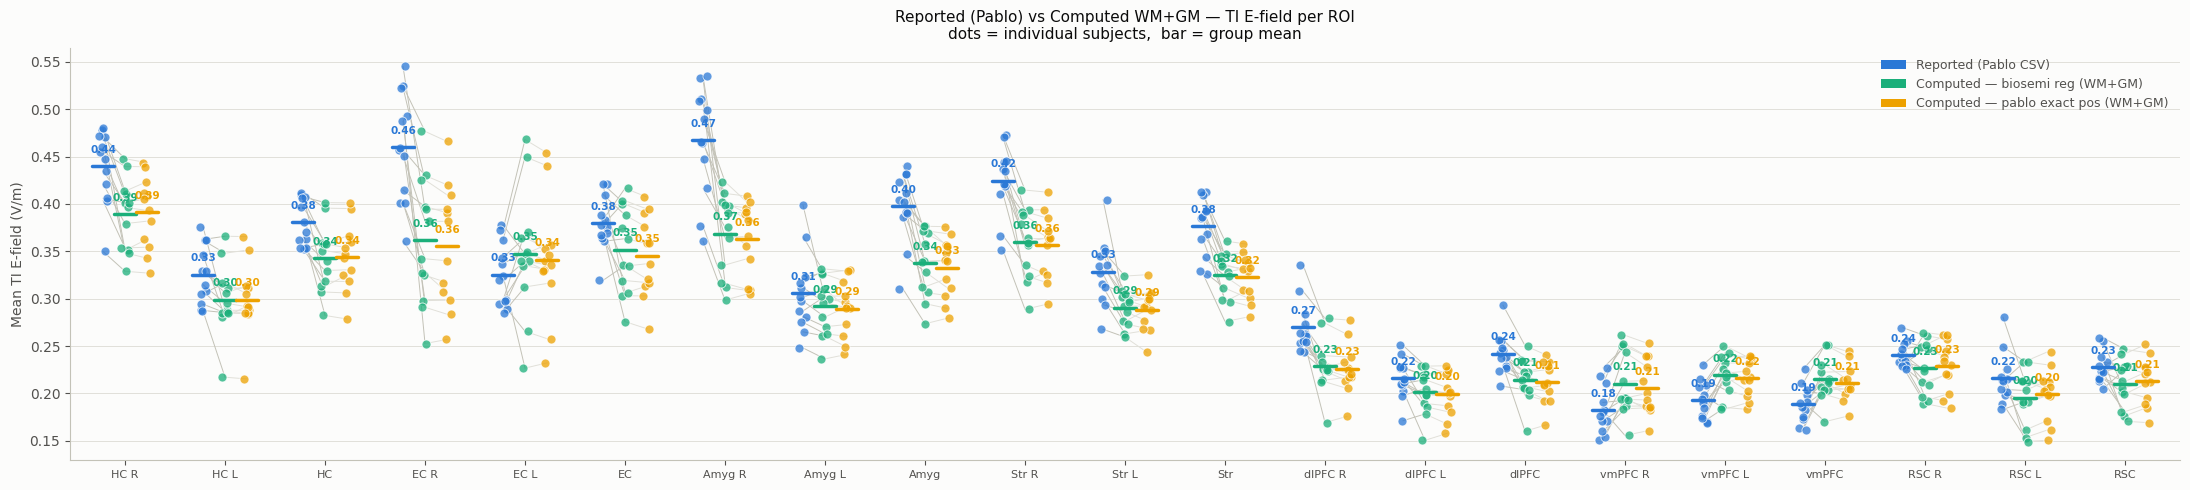

In [56]:
# ── Step 12b: strip plot — reported vs computed (WM+GM) per ROI ──────────────
# Requires tissue_results and reported_all from Step 12.
# Colors: reference palette slots 1 (blue=reported) and 2 (aqua=computed).
# Aqua is sub-3:1 on white → mean values are direct-labeled.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

C_REP  = '#2a78d6'   # slot 1 blue  — Reported (Pablo CSV)
C_CALC = '#1baf7a'   # slot 2 aqua  — Computed WM+GM [1,2]

ROI_DISPLAY = {
    'HC_R':    'HC R',
    'HC_L':    'HC L',
    'HC':      'HC',
    'EC_R':    'EC R',
    'EC_L':    'EC L',
    'EC':      'EC',
    'Amyg_R':  'Amyg R',
    'Amyg_L':  'Amyg L',
    'Amyg':    'Amyg',
    'Str_R':   'Str R',
    'Str_L':   'Str L',
    'Str':     'Str',
    'dlPFC_R': 'dlPFC R',
    'dlPFC_L': 'dlPFC L',
    'dlPFC':   'dlPFC',
    'vmPFC_R': 'vmPFC R',
    'vmPFC_L': 'vmPFC L',
    'vmPFC':   'vmPFC',
    'RSC_R':   'RSC R',
    'RSC_L':   'RSC L',
    'RSC':     'RSC',
}
ROI_NAMES  = list(ROI_DISPLAY.keys())
ROI_LABELS = list(ROI_DISPLAY.values())

rng     = np.random.default_rng(42)
GRP_OFF = 0.22   # half-gap between Reported / Computed clusters
JIT     = 0.045  # intra-cluster jitter half-width
MEAN_HW = 0.11   # half-width of the mean bar

fig, ax = plt.subplots(figsize=(22, 5))
fig.patch.set_facecolor('#fcfcfb')
ax.set_facecolor('#fcfcfb')

for xi, roi in enumerate(ROI_NAMES):
    # also connect each subject's Reported vs Computed WM+GM with a thin line
    for s in ALL_SUBJECTS:
        rep_val    = reported_all[s].get(REPORTED_KEY.get(roi, ''))
        biosemi    = tissue_results['WM+GM [1,2]'][s][roi]
        pablo_comp = tissue_results['pablo_exactpos WM+GM [1,2]'][s][roi]
        if rep_val is not None and not np.isnan(biosemi):
            ax.plot([xi - GRP_OFF, xi], [rep_val, biosemi],
                    color='#c3c2b7', linewidth=0.7, zorder=1)
        if not np.isnan(biosemi) and not np.isnan(pablo_comp):
            ax.plot([xi, xi + GRP_OFF], [biosemi, pablo_comp],
                    color='#e1e0d9', linewidth=0.7, zorder=1)

    for color, sign, label, get_val in [
        (C_REP,    -1, 'Reported',
         lambda s, r=roi: reported_all[s].get(REPORTED_KEY.get(r, ''))),
        (C_CALC,    0, 'Computed WM+GM',
         lambda s, r=roi: tissue_results['WM+GM [1,2]'][s][r]),
        ('#eda100', 1, 'Computed pablo exactpos',
         lambda s, r=roi: tissue_results['pablo_exactpos WM+GM [1,2]'][s][r]),
    ]:

        vals = np.array([get_val(s) for s in ALL_SUBJECTS], dtype=float)
        valid = vals[~np.isnan(vals)]
        if len(valid) == 0:
            continue

        xc  = xi + sign * GRP_OFF
        jit = rng.uniform(-JIT, JIT, len(valid))
        ax.scatter(xc + jit, valid, color=color, s=42, alpha=0.75,
                   linewidths=0.7, edgecolors='white', zorder=3)

        mean_val = np.nanmean(vals)
        ax.plot([xc - MEAN_HW, xc + MEAN_HW], [mean_val, mean_val],
                color=color, linewidth=2.5, solid_capstyle='round', zorder=4)
        # direct label on mean (required: aqua is sub-3:1 on light surface)
        ax.text(xc, mean_val + 0.012, f'{mean_val:.2f}',
                ha='center', va='bottom', fontsize=7.5, color=color, fontweight='bold')

ax.set_xticks(range(len(ROI_NAMES)))
ax.set_xticklabels(ROI_LABELS, fontsize=10)
ax.set_xlim(-0.55, len(ROI_NAMES) - 0.45)
ax.set_ylabel('Mean TI E-field (V/m)', fontsize=10, color='#52514e')
ax.set_title('Reported (Pablo) vs Computed WM+GM — TI E-field per ROI\n'
             'dots = individual subjects,  bar = group mean',
             fontsize=11, color='#0b0b0b')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color('#c3c2b7')
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(colors='#52514e')
ax.tick_params(axis='x', labelsize=8)

legend_handles = [
    mpatches.Patch(facecolor=C_REP,    label='Reported (Pablo CSV)'),
    mpatches.Patch(facecolor=C_CALC,   label='Computed — biosemi reg (WM+GM)'),
    mpatches.Patch(facecolor='#eda100', label='Computed — pablo exact pos (WM+GM)'),
]

ax.legend(handles=legend_handles, frameon=False, fontsize=9,
          labelcolor='#52514e', loc='upper right')

plt.tight_layout()
plt.show()


ROI            mean V/m   std V/m   mean %   std %            direction
----------------------------------------------------------------------
HC_R            -0.0506    0.0357    -11.2     7.4 always under  (12/12)
HC_L            -0.0264    0.0300     -8.0     8.9 mixed  (10↓ 2↑ / 12)
HC              -0.0379    0.0292     -9.9     7.5 mixed  (11↓ 1↑ / 12)
EC_R            -0.0980    0.0693    -20.7    13.7 always under  (12/12)
EC_L            +0.0222    0.0525     +6.8    15.8  mixed  (3↓ 9↑ / 12)
EC              -0.0281    0.0463     -7.1    11.9  mixed  (7↓ 5↑ / 12)
Amyg_R          -0.0985    0.0508    -20.5     8.8 always under  (12/12)
Amyg_L          -0.0140    0.0296     -3.9     7.8  mixed  (8↓ 4↑ / 12)
Amyg            -0.0603    0.0339    -14.9     7.8 always under  (12/12)
Str_R           -0.0650    0.0265    -15.2     5.9 always under  (12/12)
Str_L           -0.0379    0.0269    -11.0     6.6 always under  (12/12)
Str             -0.0520    0.0205    -13.6     5.0 always u

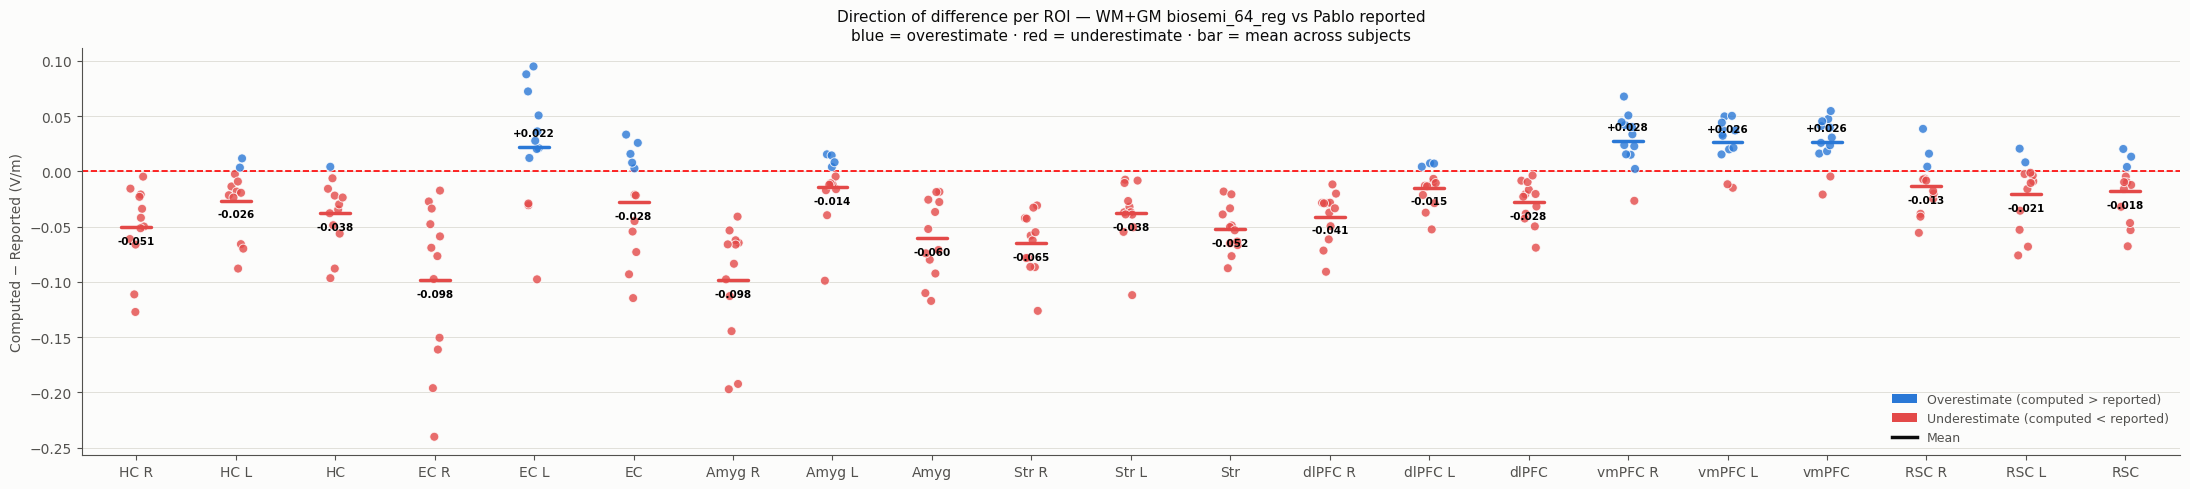

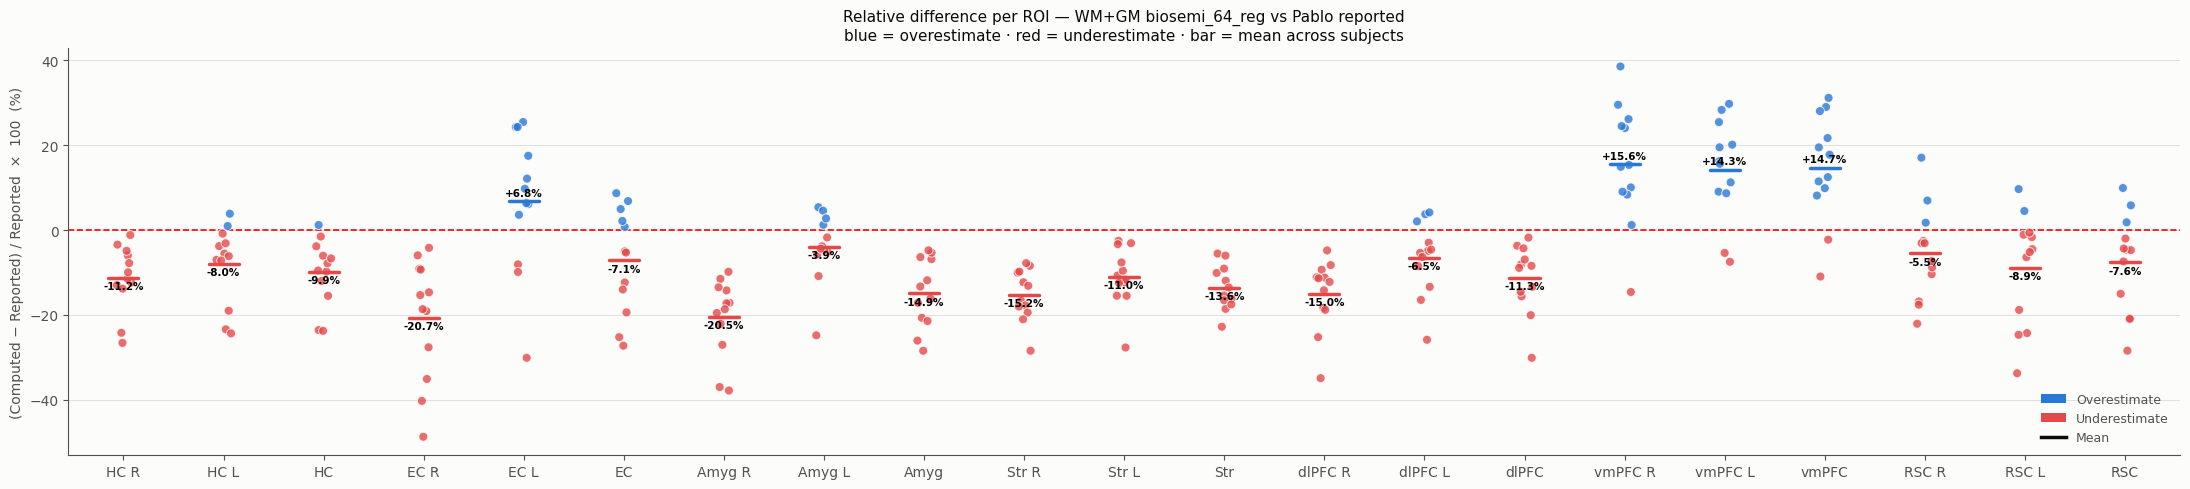

In [59]:
# ── Step 12c: systematic vs random difference analysis ────────────────────────
# WM+GM biosemi_64_reg vs Pablo reported.
# Blue dot = computed > reported (overestimate).
# Red  dot = computed < reported (underestimate).
# All same colour for a given ROI = systematic bias; mixed = subject-dependent.

import matplotlib.lines as mlines
import matplotlib.patches as mpatches

C_OVER  = '#2a78d6'   # slot 1 blue — overestimate
C_UNDER = '#e34948'   # slot 6 red  — underestimate
C_ZERO  = "#ff0000"   # baseline
C_axes  = '#52514e'   # dark gray for axes, ticks, labels

ROI_NAMES   = [n for n, _ in REGIONS]
ROI_DISPLAY = {n: n.replace('_', ' ') for n, _ in REGIONS}

# ── signed + % differences ────────────────────────────────────────────────────
diffs     = {}
pct_diffs = {}
for roi in ROI_NAMES:
    d = []
    for s in ALL_SUBJECTS:
        comp = tissue_results['WM+GM [1,2]'][s].get(roi, np.nan)
        rep  = reported_all[s].get(REPORTED_KEY.get(roi, ''))
        if rep is not None and not np.isnan(comp) and rep != 0:
            d.append((comp - rep, (comp - rep) / rep * 100))
    diffs[roi]     = np.array([x[0] for x in d])
    pct_diffs[roi] = np.array([x[1] for x in d])

# ── summary table ─────────────────────────────────────────────────────────────
print(f'{"ROI":<12} {"mean V/m":>10} {"std V/m":>9} {"mean %":>8} {"std %":>7} {"direction":>20}')
print('-' * 70)
for roi in ROI_NAMES:
    d, p = diffs[roi], pct_diffs[roi]
    if len(d) == 0:
        continue
    n_neg, n_pos, n = int(np.sum(d < 0)), int(np.sum(d > 0)), len(d)
    if n_neg == n:
        direction = f'always under  ({n}/{n})'
    elif n_pos == n:
        direction = f'always over   ({n}/{n})'
    else:
        direction = f'mixed  ({n_neg}↓ {n_pos}↑ / {n})'
    print(f'{roi:<12} {np.mean(d):>+10.4f} {np.std(d):>9.4f} '
          f'{np.mean(p):>+8.1f} {np.std(p):>7.1f} {direction:>20}')

# ── plot ──────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
fig, ax = plt.subplots(figsize=(22, 5))
fig.patch.set_facecolor('#fcfcfb')
ax.set_facecolor('#fcfcfb')

JIT, MEAN_HW = 0.08, 0.15

for xi, roi in enumerate(ROI_NAMES):
    d = diffs[roi]
    if len(d) == 0:
        continue
    colors = [C_OVER if v > 0 else C_UNDER for v in d]
    ax.scatter(xi + rng.uniform(-JIT, JIT, len(d)), d,
               color=colors, s=42, alpha=0.8, linewidths=0.7,
               edgecolors='white', zorder=3)
    mean_d = float(np.mean(d))
    bar_c  = C_OVER if mean_d > 0 else C_UNDER
    ax.plot([xi - MEAN_HW, xi + MEAN_HW], [mean_d, mean_d],
            color=bar_c, linewidth=2.5, solid_capstyle='round', zorder=4)
    va = 'bottom' if mean_d >= 0 else 'top'
    ax.text(xi, mean_d + (0.008 if mean_d >= 0 else -0.008),
            f'{mean_d:+.3f}', ha='center', va=va,
            fontsize=7.5, color='black', fontweight='bold')
# add a red line at y=0 to indicate no difference

ax.axhline(0, color=C_ZERO, linewidth=1.2, linestyle='--', zorder=2)
ax.set_xticks(range(len(ROI_NAMES)))
ax.set_xticklabels([ROI_DISPLAY[r] for r in ROI_NAMES], fontsize=10)
ax.set_xlim(-0.55, len(ROI_NAMES) - 0.45)
ax.set_ylabel('Computed − Reported (V/m)', fontsize=10, color='#52514e')
ax.set_title('Direction of difference per ROI — WM+GM biosemi_64_reg vs Pablo reported\n'
             'blue = overestimate · red = underestimate · bar = mean across subjects',
             fontsize=11, color='#0b0b0b')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(C_axes)
ax.spines['bottom'].set_color(C_axes)
ax.tick_params(colors='#52514e')

ax.legend(handles=[
    mpatches.Patch(facecolor=C_OVER,  label='Overestimate (computed > reported)'),
    mpatches.Patch(facecolor=C_UNDER, label='Underestimate (computed < reported)'),
    mlines.Line2D([], [], color='#0b0b0b', linewidth=2.5, label='Mean'),
], frameon=False, fontsize=9, labelcolor='#52514e', loc='lower right')

plt.tight_layout()
plt.show()
# ── % difference plot ─────────────────────────────────────────────────────────
rng2 = np.random.default_rng(42)
fig2, ax2 = plt.subplots(figsize=(22, 5))
fig2.patch.set_facecolor('#fcfcfb')
ax2.set_facecolor('#fcfcfb')

for xi, roi in enumerate(ROI_NAMES):
    p = pct_diffs[roi]
    if len(p) == 0:
        continue
    colors = [C_OVER if v > 0 else C_UNDER for v in p]
    ax2.scatter(xi + rng2.uniform(-JIT, JIT, len(p)), p,
                color=colors, s=42, alpha=0.8, linewidths=0.7,
                edgecolors='white', zorder=3)
    mean_p = float(np.mean(p))
    bar_c  = C_OVER if mean_p > 0 else C_UNDER
    ax2.plot([xi - MEAN_HW, xi + MEAN_HW], [mean_p, mean_p],
             color=bar_c, linewidth=2.5, solid_capstyle='round', zorder=4)
    va = 'bottom' if mean_p >= 0 else 'top'
    ax2.text(xi, mean_p + (0.8 if mean_p >= 0 else -0.8),
             f'{mean_p:+.1f}%', ha='center', va=va,
             fontsize=7.5, color='black', fontweight='bold')

ax2.axhline(0, color=C_ZERO, linewidth=1.2, linestyle='--', zorder=2)
ax2.set_xticks(range(len(ROI_NAMES)))
ax2.set_xticklabels([ROI_DISPLAY[r] for r in ROI_NAMES], fontsize=10)
ax2.set_xlim(-0.55, len(ROI_NAMES) - 0.45)
ax2.set_ylabel('(Computed − Reported) / Reported  ×  100  (%)', fontsize=10, color='#52514e')
ax2.set_title('Relative difference per ROI — WM+GM biosemi_64_reg vs Pablo reported\n'
              'blue = overestimate · red = underestimate · bar = mean across subjects',
              fontsize=11, color='#0b0b0b')
ax2.yaxis.grid(True, color='#e1e0d9', linewidth=0.7, zorder=0)
ax2.set_axisbelow(True)
for sp in ['top', 'right']:
    ax2.spines[sp].set_visible(False)
ax2.spines['left'].set_color(C_axes)
ax2.spines['bottom'].set_color(C_axes)
ax2.tick_params(colors='#52514e')
ax2.legend(handles=[
    mpatches.Patch(facecolor=C_OVER,  label='Overestimate'),
    mpatches.Patch(facecolor=C_UNDER, label='Underestimate'),
    mlines.Line2D([], [], color='#0b0b0b', linewidth=2.5, label='Mean'),
], frameon=False, fontsize=9, labelcolor='#52514e', loc='lower right')

plt.tight_layout()
plt.show()


In [63]:
# ── Step 12c: sphere analysis per electrode (biosemi_64_reg, r=9.75mm) ───────
# For each subject × electrode, find nearest WM+GM element to the electrode
# position, then average TI over all WM+GM elements within SPHERE_R mm.
# Electrode positions come from the FEM ch1/ch2 logs.
# Requires: _load_or_build_ti_cache, manual_cfgs, reported_all (Steps 2, 12).

import re

SPHERE_R = 9.75   # mm — half of 19.5mm electrode diameter
FEM_KEY  = 'manual_fem_biosemi_64_reg'

ELEC_KEYS = ['Ch1_1', 'Ch1_2', 'Ch2_1', 'Ch2_2']
ELEC_REPORTED = {k: f'{k}_u' for k in ELEC_KEYS}

sphere_results = {s: {} for s in ALL_SUBJECTS}

for subject in ALL_SUBJECTS:
    base  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                         f'sub-{subject}', 'comparison', FEM_KEY)
    logs1 = sorted(glob.glob(os.path.join(base, 'ch1', '*.log')))
    logs2 = sorted(glob.glob(os.path.join(base, 'ch2', '*.log')))
    c1    = _read_electrode_centres_from_log(logs1[-1]) if logs1 else []
    c2    = _read_electrode_centres_from_log(logs2[-1]) if logs2 else []
    if len(c1) < 2 or len(c2) < 2:
        print(f'[skip] {subject}: electrode log incomplete')
        continue

    elec_pos = {
        'Ch1_1': np.array(c1[0]),
        'Ch1_2': np.array(c1[1]),
        'Ch2_1': np.array(c2[0]),
        'Ch2_2': np.array(c2[1]),
    }

    # Load TI cache
    ti, elm_volumes, elm_tags, elm_lbl = _load_or_build_ti_cache(subject, FEM_KEY)

    # Recompute centroids from mesh (same crop as cache so indices align)
    ch1_msh = sorted(glob.glob(os.path.join(base, 'ch1', '*.msh')))
    mt      = mesh_io.read_msh(ch1_msh[0]).crop_mesh(tags=CACHE_TAGS)
    nodes   = mt.nodes.node_coord
    conn    = mt.elm.node_number_list[:, :4] - 1
    centroids = nodes[conn].mean(axis=1)
    del mt; gc.collect()

    # Restrict to WM+GM
    wm_gm_mask = np.isin(elm_tags, [1, 2])
    c_sub  = centroids[wm_gm_mask]
    ti_sub = ti[wm_gm_mask]
    vl_sub = elm_volumes[wm_gm_mask]

    for key, pos in elec_pos.items():
        # Project electrode onto brain surface: nearest WM+GM centroid
        dist_to_elec  = np.linalg.norm(c_sub - pos, axis=1)
        sphere_center = c_sub[np.argmin(dist_to_elec)]

        # All WM+GM elements within SPHERE_R of that surface point
        dist      = np.linalg.norm(c_sub - sphere_center, axis=1)
        in_sphere = dist < SPHERE_R
        sphere_results[subject][key] = (
            _vol_mean_capped(ti_sub[in_sphere], vl_sub[in_sphere])
            if in_sphere.any() else np.nan
        )


    del ti, elm_volumes, elm_tags, elm_lbl, centroids, c_sub, ti_sub, vl_sub
    gc.collect()

# ── print comparison table ────────────────────────────────────────────────────
mc = manual_cfgs  # shorthand
header = f'{"subject":<8} {"":>6}' + ''.join(
    f'{"comp":>10}{"rep":>10}' for _ in ELEC_KEYS)
subhdr = f'{"":14}' + ''.join(
    f'{k:>20}' for k in ELEC_KEYS)
print(subhdr)

for subject in ALL_SUBJECTS:
    names = [mc[subject]['ch1_plus'], mc[subject]['ch1_minus'],
             mc[subject]['ch2_plus'], mc[subject]['ch2_minus']]
    row = f'{subject:<8} '
    for key, name in zip(ELEC_KEYS, names):
        comp = sphere_results[subject].get(key, np.nan)
        rep  = reported_all[subject].get(ELEC_REPORTED[key])
        comp_s = f'{comp:.4f}' if not np.isnan(comp) else '      —'
        rep_s  = f'{rep:.4f}' if rep is not None else '      —'
        row += f'[{name}] {comp_s} {rep_s}  '
    print(row)


  [cache] 73T01/manual_fem_biosemi_64_reg
  [cache] 73T02/manual_fem_biosemi_64_reg
  [cache] 73T03/manual_fem_biosemi_64_reg
  [cache] 73T04/manual_fem_biosemi_64_reg
  [cache] 73T05/manual_fem_biosemi_64_reg
  [cache] 73T06/manual_fem_biosemi_64_reg
  [cache] 73T07/manual_fem_biosemi_64_reg
  [cache] 73T09/manual_fem_biosemi_64_reg
  [cache] 73T10/manual_fem_biosemi_64_reg
  [cache] 73T11/manual_fem_biosemi_64_reg
  [cache] 73T12/manual_fem_biosemi_64_reg
  [cache] 73T14/manual_fem_biosemi_64_reg
                             Ch1_1               Ch1_2               Ch2_1               Ch2_2
73T01    [F8] 0.2230 0.2626  [FC3] 0.2168 0.2260  [P5] 0.2111 0.2225  [TP10] 0.0853 0.0791  
73T02    [F8] 0.1926 0.2950  [FT9] 0.1858 0.2202  [PO9] 0.1645 0.1687  [CP6] 0.1968 0.2744  
73T03    [F8] 0.2724 0.2778  [FT9] 0.2650 0.2403  [PO9] 0.1413 0.1344  [C6] 0.2392 0.2858  
73T04    [F8] 0.2260 0.2434  [FT9] 0.2330 0.2421  [PO9] 0.1833 0.1703  [CP6] 0.2715 0.2878  
73T05    [F8] 0.2921 0.3566  [

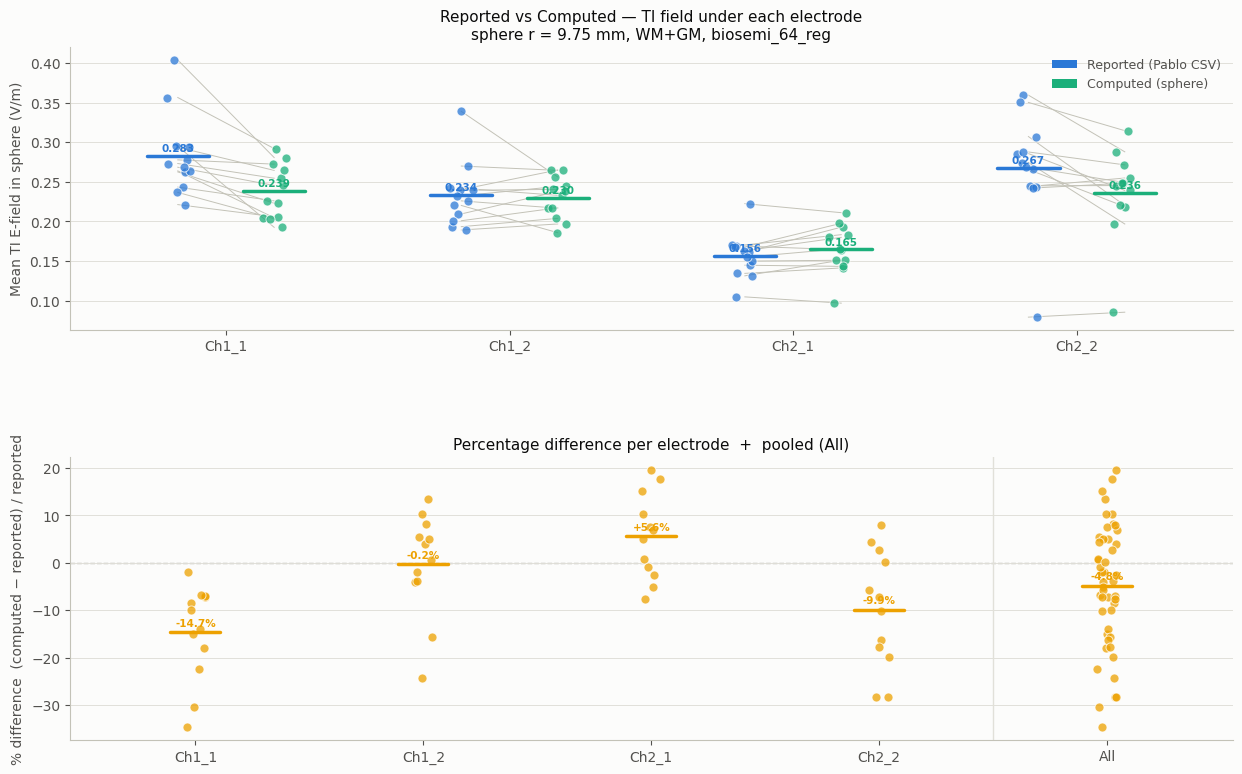

Overall  N=48  mean=-4.8%  std=12.9%  median=-3.9%  range=[-34.7%, 19.6%]

electrode    mean %diff      std    n
Ch1_1            -14.7%      9.7%   12
Ch1_2             -0.2%     10.4%   12
Ch2_1             +5.6%      8.6%   12
Ch2_2             -9.9%     11.9%   12


In [67]:
# ── Step 12d: sphere strip plot + % difference breakdown ─────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

C_REP   = '#2a78d6'
C_CALC  = '#1baf7a'
C_PCT   = '#eda100'   # slot 3 yellow — % difference

rng     = np.random.default_rng(42)
GRP_OFF = 0.17
JIT     = 0.045
MEAN_HW = 0.11

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9),
                                gridspec_kw={'hspace': 0.45})
for ax in (ax1, ax2):
    fig.patch.set_facecolor('#fcfcfb')
    ax.set_facecolor('#fcfcfb')

pct_diffs_per_elec = {k: [] for k in ELEC_KEYS}

# ── ax1: V/m strip plot ───────────────────────────────────────────────────────
for xi, key in enumerate(ELEC_KEYS):
    rep_key = ELEC_REPORTED[key]
    for s in ALL_SUBJECTS:
        rep  = reported_all[s].get(rep_key)
        comp = sphere_results[s].get(key, np.nan)
        if rep is not None and not np.isnan(comp):
            ax1.plot([xi - GRP_OFF, xi + GRP_OFF], [rep, comp],
                     color='#c3c2b7', linewidth=0.7, zorder=1)
            if rep != 0:
                pct_diffs_per_elec[key].append((comp - rep) / rep * 100)

    for color, sign, get_val in [
        (C_REP,  -1, lambda s, k=rep_key: reported_all[s].get(k)),
        (C_CALC,  1, lambda s, k=key:     sphere_results[s].get(k, np.nan)),
    ]:
        vals  = np.array([get_val(s) for s in ALL_SUBJECTS], dtype=float)
        valid = vals[~np.isnan(vals)]
        if not len(valid):
            continue
        xc  = xi + sign * GRP_OFF
        jit = rng.uniform(-JIT, JIT, len(valid))
        ax1.scatter(xc + jit, valid, color=color, s=42, alpha=0.75,
                    linewidths=0.7, edgecolors='white', zorder=3)
        mean_val = np.nanmean(vals)
        ax1.plot([xc - MEAN_HW, xc + MEAN_HW], [mean_val, mean_val],
                 color=color, linewidth=2.5, solid_capstyle='round', zorder=4)
        ax1.text(xc, mean_val + 0.003, f'{mean_val:.3f}',
                 ha='center', va='bottom', fontsize=7.5,
                 color=color, fontweight='bold')

ax1.set_xticks(range(len(ELEC_KEYS)))
ax1.set_xticklabels(ELEC_KEYS, fontsize=10)
ax1.set_xlim(-0.55, len(ELEC_KEYS) - 0.45)
ax1.set_ylabel('Mean TI E-field in sphere (V/m)', fontsize=10, color='#52514e')
ax1.set_title(
    f'Reported vs Computed — TI field under each electrode\n'
    f'sphere r = {SPHERE_R} mm, WM+GM, biosemi_64_reg',
    fontsize=11, color='#0b0b0b')
ax1.yaxis.grid(True, color='#e1e0d9', linewidth=0.7, zorder=0)
ax1.set_axisbelow(True)
for sp in ['top', 'right']:
    ax1.spines[sp].set_visible(False)
ax1.spines['left'].set_color('#c3c2b7')
ax1.spines['bottom'].set_color('#c3c2b7')
ax1.tick_params(colors='#52514e')
ax1.legend(handles=[
    mpatches.Patch(facecolor=C_REP,  label='Reported (Pablo CSV)'),
    mpatches.Patch(facecolor=C_CALC, label='Computed (sphere)'),
], frameon=False, fontsize=9, labelcolor='#52514e', loc='upper right')

# ── ax2: % difference — per electrode + pooled ───────────────────────────────
all_pct   = np.concatenate([np.array(v) for v in pct_diffs_per_elec.values()])
pct_groups = [(k, np.array(pct_diffs_per_elec[k])) for k in ELEC_KEYS]
pct_groups.append(('All', all_pct))

ax2.axhline(0, color='#898781', linewidth=0.9, linestyle='--', zorder=0)

for xi, (label, vals) in enumerate(pct_groups):
    if not len(vals):
        continue
    jit = rng.uniform(-JIT, JIT, len(vals))
    ax2.scatter(xi + jit, vals, color=C_PCT, s=42, alpha=0.75,
                linewidths=0.7, edgecolors='white', zorder=3)
    mean_val = vals.mean()
    ax2.plot([xi - MEAN_HW, xi + MEAN_HW], [mean_val, mean_val],
             color=C_PCT, linewidth=2.5, solid_capstyle='round', zorder=4)
    ax2.text(xi, mean_val + 0.8, f'{mean_val:+.1f}%',
             ha='center', va='bottom', fontsize=7.5,
             color=C_PCT, fontweight='bold')

ax2.set_xticks(range(len(pct_groups)))
ax2.set_xticklabels([g[0] for g in pct_groups], fontsize=10)
ax2.set_xlim(-0.55, len(pct_groups) - 0.45)
ax2.set_ylabel('% difference  (computed − reported) / reported', fontsize=10, color='#52514e')
ax2.set_title('Percentage difference per electrode  +  pooled (All)',
              fontsize=11, color='#0b0b0b')
ax2.yaxis.grid(True, color='#e1e0d9', linewidth=0.7, zorder=0)
ax2.set_axisbelow(True)
for sp in ['top', 'right']:
    ax2.spines[sp].set_visible(False)
ax2.spines['left'].set_color('#c3c2b7')
ax2.spines['bottom'].set_color('#c3c2b7')
ax2.tick_params(colors='#52514e')

# Add a vertical separator before "All"
ax2.axvline(len(ELEC_KEYS) - 0.5, color='#e1e0d9', linewidth=1.0, zorder=0)

plt.show()

# ── printed summary ───────────────────────────────────────────────────────────
print(f'Overall  N={len(all_pct)}  '
      f'mean={all_pct.mean():+.1f}%  std={all_pct.std():.1f}%  '
      f'median={np.median(all_pct):+.1f}%  '
      f'range=[{all_pct.min():.1f}%, {all_pct.max():.1f}%]')
print()
print(f'{"electrode":<10} {"mean %diff":>12} {"std":>8} {"n":>4}')
for key in ELEC_KEYS:
    d = np.array(pct_diffs_per_elec[key])
    if len(d):
        print(f'{key:<10} {d.mean():>+11.1f}%  {d.std():>7.1f}%  {len(d):>3}')


### Below cells are more for the 3D visualization of the ROI and non-ROI

In [37]:
# ── Step 13: export per-subject ROI label mesh for Gmsh ──────────────────────
# Uses shared label constants from helpers. Label values for Gmsh coloring:
#   0=unlabeled, 1=HC, 2=EC, 3=vmPFC (L+R combined), 4=RSC (L+R combined)

LABEL_VALUES = {
    'HC':    (1.0, HC_LABELS),
    'EC':    (2.0, EC_LABELS),
    'vmPFC': (3.0, VMPFC_R_LBL | VMPFC_L_LBL),
    'RSC':   (4.0, RSC_R_LBL   | RSC_L_LBL),
}

for subject in ALL_SUBJECTS:
    m2m_path  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                              f'sub-{subject}', f'm2m_{subject}')
    msh       = mesh_io.read_msh(os.path.join(m2m_path, f'{subject}.msh'))
    msh_brain = msh.crop_mesh(tags=[1, 2])

    nodes     = msh_brain.nodes.node_coord
    conn      = msh_brain.elm.node_number_list[:, :4] - 1
    centroids = nodes[conn].mean(axis=1)

    elm_lbl   = _atlas_elm_labels(subject, PROJECT_DIR, centroids)
    roi_field = np.zeros(len(centroids), dtype=float)
    for name, (val, labels) in LABEL_VALUES.items():
        roi_field[np.isin(elm_lbl, list(labels))] = val

    msh_brain.elmdata = [mesh_io.ElementData(roi_field, name='ROI_labels')]
    out_path = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                             f'sub-{subject}', 'comparison',
                             f'sub-{subject}_roi_labels.msh')
    mesh_io.write_msh(msh_brain, out_path)
    print(f'sub-{subject}: HC={np.sum(roi_field==1)}  EC={np.sum(roi_field==2)}  '
          f'vmPFC={np.sum(roi_field==3)}  RSC={np.sum(roi_field==4)}  '
          f'unlabeled={np.sum(roi_field==0)}')

    del msh, msh_brain, centroids, elm_lbl, roi_field
    gc.collect()


sub-73T01: HC=8899  EC=525  vmPFC=65200  RSC=9416  unlabeled=1565375
sub-73T02: HC=7904  EC=916  vmPFC=86908  RSC=8345  unlabeled=1462713
sub-73T03: HC=10183  EC=1046  vmPFC=66489  RSC=7761  unlabeled=1498898
sub-73T04: HC=7017  EC=1101  vmPFC=94832  RSC=10638  unlabeled=1580999
sub-73T05: HC=10855  EC=1183  vmPFC=94762  RSC=9723  unlabeled=1771848
sub-73T06: HC=9255  EC=1000  vmPFC=74335  RSC=9203  unlabeled=1708600
sub-73T07: HC=8115  EC=558  vmPFC=80797  RSC=7203  unlabeled=1580217
sub-73T09: HC=9239  EC=972  vmPFC=99413  RSC=8822  unlabeled=1653966
sub-73T10: HC=12239  EC=1070  vmPFC=93749  RSC=7725  unlabeled=1752946
sub-73T11: HC=8944  EC=364  vmPFC=94063  RSC=8892  unlabeled=1705894
sub-73T12: HC=7952  EC=590  vmPFC=70334  RSC=7209  unlabeled=1346088
sub-73T14: HC=7474  EC=888  vmPFC=80593  RSC=9104  unlabeled=1587590


In [48]:
# ── Step 14: export brain TI view mesh + .geo per subject × variant ──────────
# Set FORCE_REGEN = True after re-running FEM sims (new electrode params).
FORCE_REGEN = False

VARIANTS = [
    'manual_fem_biosemi_64_reg',
    'manual_fem_pablo_exactpos',
]

VMPC_LBL = VMPFC_R_LBL | VMPFC_L_LBL
RSC_LBL  = RSC_R_LBL   | RSC_L_LBL

MASKED_REGIONS = [
    ('TI_HC',    HC_LABELS),
    ('TI_EC',    EC_LABELS),
    ('TI_vmPFC', VMPC_LBL),
    ('TI_RSC',   RSC_LBL),
]

def _read_electrode_centres_from_log(log_path):
    txt = open(log_path, errors='replace').read()
    return [list(map(float, c.split(',')))
            for c in re.findall(r'centre:\s*\[([^\]]+)\]', txt)]

def _get_msh_paths_for_variant(subject, variant, project_dir):
    base = os.path.join(project_dir, 'derivatives', 'SimNIBS',
                        f'sub-{subject}', 'comparison', variant)
    msh1 = sorted(glob.glob(os.path.join(base, 'ch1', '*.msh')))
    msh2 = sorted(glob.glob(os.path.join(base, 'ch2', '*.msh')))
    if not msh1 or not msh2:
        raise FileNotFoundError(f'FEM meshes missing for {subject}/{variant}')
    return msh1[0], msh2[0]

for subject in ALL_SUBJECTS:
    mc       = manual_cfgs[subject]
    el_names = [mc['ch1_plus'], mc['ch1_minus'], mc['ch2_plus'], mc['ch2_minus']]

    for variant in VARIANTS:
        base      = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                                 f'sub-{subject}', 'comparison', variant)
        msh_name  = f'sub-{subject}_TI_view.msh'
        scalp_rel = f'../sub-{subject}_scalp.msh'
        msh_path  = os.path.join(base, msh_name)
        geo_path  = os.path.join(base, f'sub-{subject}_TI_with_electrodes.geo')

        if not FORCE_REGEN and os.path.isfile(msh_path) and os.path.isfile(geo_path):
            print(f'[skip] {subject}/{variant}')
            continue

        try:
            msh1_path, msh2_path = _get_msh_paths_for_variant(subject, variant, PROJECT_DIR)
        except FileNotFoundError as e:
            print(f'[missing] {subject}/{variant}: {e}')
            continue

        print(f'sub-{subject} / {variant} ...')

        msh_brain = mesh_io.read_msh(msh1_path).crop_mesh(tags=[1, 2])
        nodes     = msh_brain.nodes.node_coord
        conn      = msh_brain.elm.node_number_list[:, :4] - 1
        centroids = nodes[conn].mean(axis=1)

        ef1 = next(d for d in msh_brain.elmdata if d.field_name == 'E').value
        ef2 = next(d for d in
                   mesh_io.read_msh(msh2_path).crop_mesh(tags=[1, 2]).elmdata
                   if d.field_name == 'E').value
        ti  = TI.get_maxTI(ef1, ef2)

        elm_lbl   = _atlas_elm_labels(subject, PROJECT_DIR, centroids)
        roi_field = np.zeros(len(centroids), dtype=float)
        for val, labels in [(1., HC_LABELS), (2., EC_LABELS),
                             (3., VMPC_LBL),  (4., RSC_LBL)]:
            roi_field[np.isin(elm_lbl, list(labels))] = val

        fields = [mesh_io.ElementData(ti,        name='TI_V_per_m'),
                  mesh_io.ElementData(roi_field,  name='ROI_label')]
        for fname, labels in MASKED_REGIONS:
            masked = np.full(len(centroids), np.nan)
            mask   = np.isin(elm_lbl, list(labels))
            masked[mask] = ti[mask]
            fields.append(mesh_io.ElementData(masked, name=fname))

        msh_brain.elmdata = fields
        mesh_io.write_msh(msh_brain, msh_path)

        del msh_brain, nodes, conn, centroids, ef1, ef2, ti, elm_lbl, roi_field, fields
        gc.collect()

        # ── .geo: electrode markers ───────────────────────────────────────────
        if variant == 'manual_fem_pablo_exactpos' and subject in PABLO_ELECTRODES:
            pablo   = PABLO_ELECTRODES[subject]
            centres = [pablo[n].tolist() for n in el_names]
        else:
            logs1 = sorted(glob.glob(os.path.join(base, 'ch1', '*.log')))
            logs2 = sorted(glob.glob(os.path.join(base, 'ch2', '*.log')))
            c1 = _read_electrode_centres_from_log(logs1[-1]) if logs1 else []
            c2 = _read_electrode_centres_from_log(logs2[-1]) if logs2 else []
            centres = [c1[0], c1[1], c2[0], c2[1]] if len(c1) >= 2 and len(c2) >= 2 else None

        geo_lines = [
            f'// sub-{subject} / {variant}\n\n',
            f'Merge "{msh_name}";\n',
            f'Merge "{scalp_rel}";\n\n',
        ]

        if centres:
            for i, (name, coord) in enumerate(zip(el_names, centres), 1):
                x, y, z = coord
                geo_lines.append(f'Point({i}) = {{{x:.4f}, {y:.4f}, {z:.4f}, 5.0}};\n')
                geo_lines.append(f'Physical Point("{name}") = {{{i}}};\n')
        with open(geo_path, 'w') as f:
            f.writelines(geo_lines)

        print(f'  -> {msh_name}  +  {os.path.basename(geo_path)}')

print('\nOpen sub-{{id}}_TI_with_electrodes.geo in Gmsh after running Step 15.')


sub-73T01 / manual_fem_biosemi_64_reg ...
  -> sub-73T01_TI_view.msh  +  sub-73T01_TI_with_electrodes.geo
sub-73T01 / manual_fem_pablo_exactpos ...
  -> sub-73T01_TI_view.msh  +  sub-73T01_TI_with_electrodes.geo
sub-73T02 / manual_fem_biosemi_64_reg ...
  -> sub-73T02_TI_view.msh  +  sub-73T02_TI_with_electrodes.geo
sub-73T02 / manual_fem_pablo_exactpos ...
  -> sub-73T02_TI_view.msh  +  sub-73T02_TI_with_electrodes.geo
sub-73T03 / manual_fem_biosemi_64_reg ...
  -> sub-73T03_TI_view.msh  +  sub-73T03_TI_with_electrodes.geo
sub-73T03 / manual_fem_pablo_exactpos ...
  -> sub-73T03_TI_view.msh  +  sub-73T03_TI_with_electrodes.geo
sub-73T04 / manual_fem_biosemi_64_reg ...
  -> sub-73T04_TI_view.msh  +  sub-73T04_TI_with_electrodes.geo
sub-73T04 / manual_fem_pablo_exactpos ...
  -> sub-73T04_TI_view.msh  +  sub-73T04_TI_with_electrodes.geo
sub-73T05 / manual_fem_biosemi_64_reg ...
  -> sub-73T05_TI_view.msh  +  sub-73T05_TI_with_electrodes.geo
sub-73T05 / manual_fem_pablo_exactpos ...
  ->

In [49]:
# ── Step 15: write lightweight scalp mesh per subject ───────────────────────
# Writes comparison/sub-{id}_scalp.msh — just the scalp elements (tag=5)
# from the head model, no field data.  Referenced by all the
# _TI_with_electrodes.geo files as ../sub-{id}_scalp.msh.
# One file per subject (scalp doesn't change between variants).

for subject in ALL_SUBJECTS:
    out_path = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                             f'sub-{subject}', 'comparison',
                             f'sub-{subject}_scalp.msh')
    if os.path.isfile(out_path):
        print(f'[skip] sub-{subject} scalp already exists')
        continue

    m2m_path  = os.path.join(PROJECT_DIR, 'derivatives', 'SimNIBS',
                              f'sub-{subject}', f'm2m_{subject}')
    msh       = mesh_io.read_msh(os.path.join(m2m_path, f'{subject}.msh'))
    msh_scalp = msh.crop_mesh(tags=[5])
    msh_scalp.elmdata = []   # no field data needed, pure geometry
    mesh_io.write_msh(msh_scalp, out_path)
    print(f'sub-{subject}: {out_path}  ({msh_scalp.elm.nr} elements)')

    del msh, msh_scalp
    gc.collect()

print('\nScalp meshes written. Now run Step 14, then open')
print('sub-{id}_TI_with_electrodes.geo in Gmsh.')
print('In Gmsh: scalp is a separate Physical Volume — toggle via')
print('Tools → Visibility → Physical groups, or the Visibility panel.')


[skip] sub-73T01 scalp already exists
[skip] sub-73T02 scalp already exists
[skip] sub-73T03 scalp already exists
[skip] sub-73T04 scalp already exists
[skip] sub-73T05 scalp already exists
[skip] sub-73T06 scalp already exists
[skip] sub-73T07 scalp already exists
[skip] sub-73T09 scalp already exists
[skip] sub-73T10 scalp already exists
[skip] sub-73T11 scalp already exists
[skip] sub-73T12 scalp already exists
[skip] sub-73T14 scalp already exists

Scalp meshes written. Now run Step 14, then open
sub-{id}_TI_with_electrodes.geo in Gmsh.
In Gmsh: scalp is a separate Physical Volume — toggle via
Tools → Visibility → Physical groups, or the Visibility panel.
